In [1]:
import numpy as np
from matplotlib import pyplot as plt

import data
import output
import video

SEGMENT_NAMES = ["Unassigned", "Extra-CSF", "GM", "WM", "Deep GM", "Brainstem+Pons"]

def format_segment_label(seg_id):
    name = SEGMENT_NAMES[seg_id] if 0 <= seg_id < len(SEGMENT_NAMES) else f"Unknown-{seg_id}"
    return f"Segment {seg_id} ({name})"

VOLUMES_DIR = output.get_dir("volumes")
SEG_PLOTS_DIR = output.get_dir("seg_plots")

In [2]:
echo_times = data.get_echo_times()
print(echo_times)

ids = data.get_ids()
print(ids)

[13.0, 16.0, 20.0, 25.0, 30.0, 40.0, 50.0, 85.0, 100.0, 150.0]
[11610, 13267, 13620, 14121, 14416, 15516, 15757, 16926, 17065, 18966, 21302, 21511, 22313, 22598, 23128, 23140, 24217, 24300, 25316, 25985, 26132, 27155, 28717, 28999, 30002, 30142, 30750, 31084, 32437, 33936, 34160, 35162, 35837, 35893, 36152, 36395, 36559, 36577, 36937, 37648, 37808, 38475, 38479, 39341, 39887, 40818, 42259, 42959, 43105, 43203, 43607, 44254, 44631, 45148, 45195, 45442, 45858, 46431, 46558, 46831, 47318, 47476, 47719, 47931, 48142, 48536, 48775, 48996, 49479, 49589, 49706, 50493, 50523, 50846, 51795, 52422, 52653, 53459, 55894, 56643, 58846, 59011, 60112, 60962, 62078, 62943, 63959, 65088, 65750, 65751, 66036, 66302, 66610, 66734, 67358, 67504, 68990, 69131, 69241, 70915, 71479, 71935, 71981, 72993, 74067, 74131, 74343, 76780, 76797, 78004, 78130, 78978, 79717, 79815, 80621, 80643, 80743, 81324, 81555, 81926, 82329, 82343, 82845, 83677, 83747, 85253, 85411, 85904, 85981, 88031, 88335, 91922, 92050, 92267

### 1. Visualizing the Segmentation Maps

In [3]:
# Inspect a dataset for a given ID
subject_id = data.get_ids()[0]
dataset = data.load_dataset(subject_id)

print(f"ID: {dataset.id}")
print(f"reg shape: {np.array(dataset.reg).shape}")   # (x, y, z, time)
print(f"seg shape: {np.array(dataset.seg).shape}")   # (x, y, z, segments)
print(f"mask shape: {np.array(dataset.mask).shape}")  # (x, y, z)

ID: 11610
reg shape: (96, 96, 51, 10)
seg shape: (96, 96, 51, 6)
mask shape: (96, 96, 51)


/var/folders/4t/yyv2xt5d5711qlypt6w9j0c40000gn/T/ipykernel_81442/3863636922.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  print(f"reg shape: {np.array(dataset.reg).shape}")   # (x, y, z, time)
/var/folders/4t/yyv2xt5d5711qlypt6w9j0c40000gn/T/ipykernel_81442/3863636922.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  print(f"seg shape: {np.array(dataset.seg).shape}")   # (x, y, z, segments)
/var/folders/4t/yyv2xt5d5711qlypt6w9j0c40000gn/T/ipykernel_81442/3863636922.

/var/folders/4t/yyv2xt5d5711qlypt6w9j0c40000gn/T/ipykernel_81442/1008807087.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  reg = np.array(dataset.reg)
/var/folders/4t/yyv2xt5d5711qlypt6w9j0c40000gn/T/ipykernel_81442/1008807087.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  seg = np.array(dataset.seg)


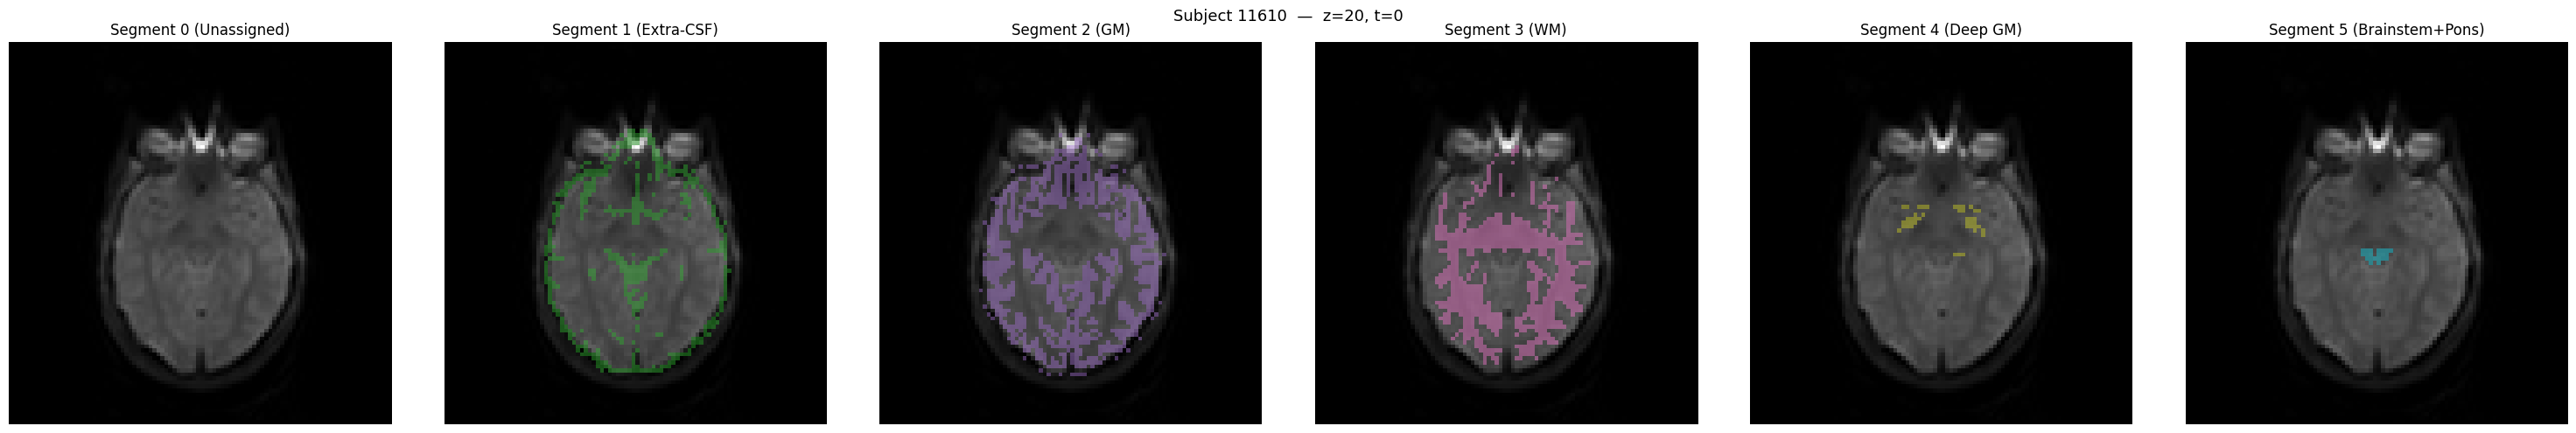

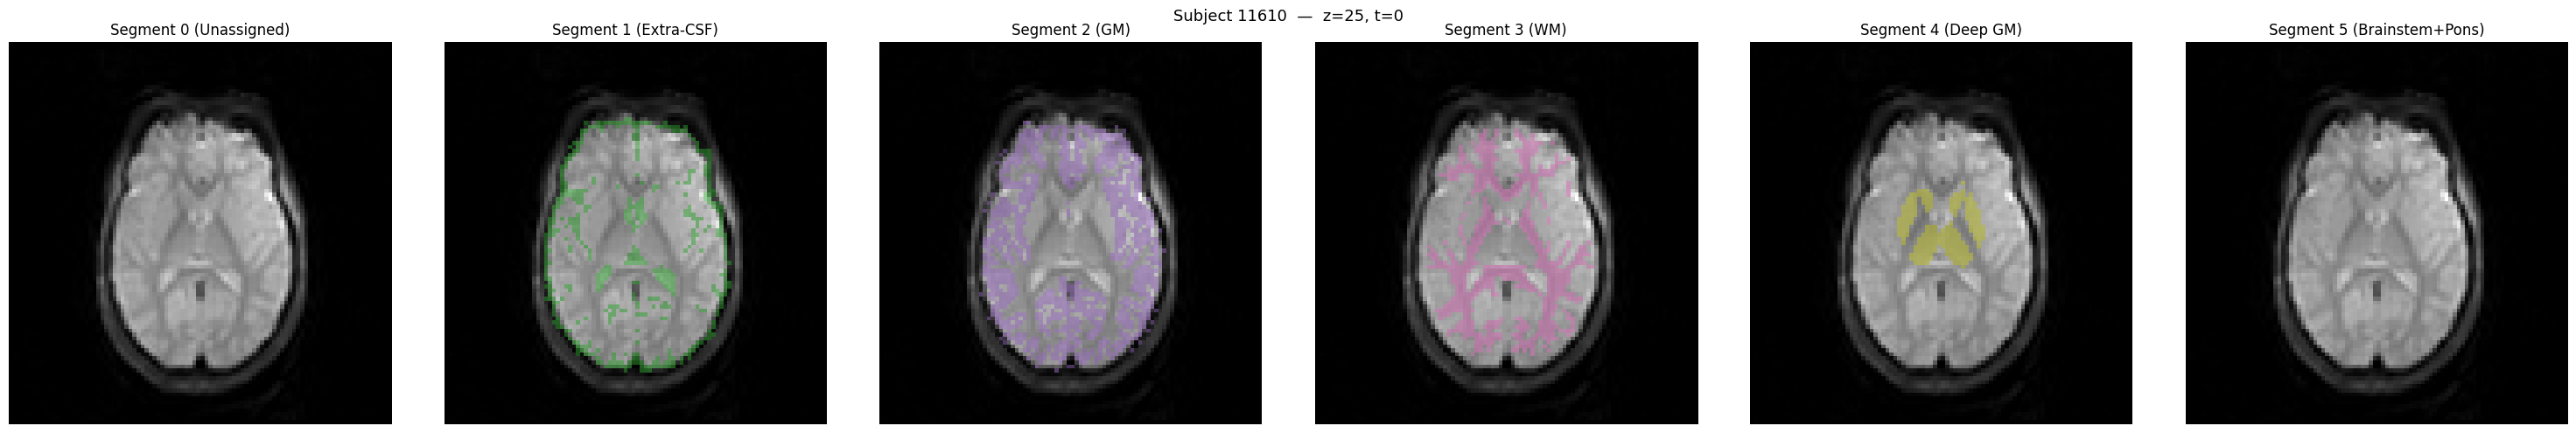

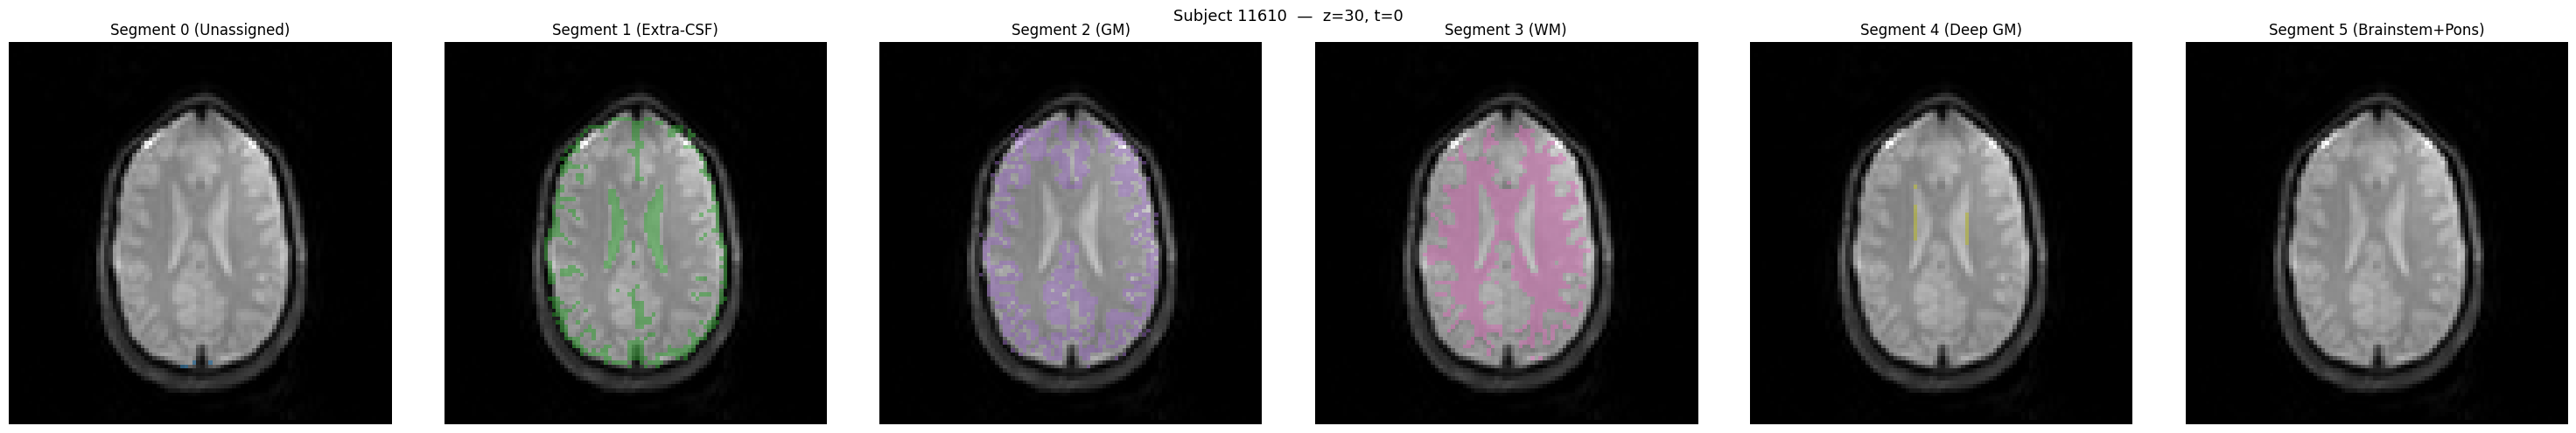

In [4]:
def show_seg_overlay(id, z_slice=25, time_step=0, alpha=0.5):
    """Overlay each segment's spatial footprint on a brain slice for the given subject id."""
    dataset = data.load_dataset(id)
    reg = np.array(dataset.reg)
    seg = np.array(dataset.seg)

    brain = reg[:, :, z_slice, time_step]
    seg_slice = seg[:, :, z_slice, :]   # (x, y, n_segments)
    n_segments = seg_slice.shape[-1]

    label_map = np.argmax(seg_slice, axis=-1).astype(float)   # (x, y), values 0..n_segments-1
    any_seg = seg_slice.max(axis=-1) > 0

    fig, axes = plt.subplots(1, n_segments, figsize=(5 * n_segments, 5))
    if n_segments == 1:
        axes = [axes]

    for seg_id in range(n_segments):
        ax = axes[seg_id]
        # Show the label_map value only where this segment dominates
        masked = np.ma.masked_where(~(any_seg & (label_map == seg_id)), label_map)

        ax.imshow(brain.T, origin="lower", cmap="gray")
        ax.imshow(masked.T, origin="lower", cmap="tab10",
                  vmin=0, vmax=n_segments - 1, alpha=alpha)
        ax.set_title(format_segment_label(seg_id))
        ax.axis("off")

    fig.suptitle(f"Subject {id}  —  z={z_slice}, t={time_step}", fontsize=13)
    plt.tight_layout()
    plt.show()

# Show for a few axial slices
for z in [20, 25, 30]:
    show_seg_overlay(subject_id, z_slice=z)

In [5]:
from matplotlib.animation import ArtistAnimation

def make_seg_sweep_z(id, time_step=0, alpha=0.5):
    """Per segment: video sweeping through z-slices at a fixed echo time."""
    dataset = data.load_dataset(id)
    reg = np.array(dataset.reg)
    seg = np.array(dataset.seg)
    n_z = reg.shape[2]
    n_segments = seg.shape[-1]
    out_dir = output.get_dir(id)

    for seg_id in range(n_segments):
        fig, ax = plt.subplots(figsize=(6, 6))
        fig.suptitle(f"Subject {id} — {format_segment_label(seg_id)} (sweep z)")
        ax.axis("off")

        artists = []
        for z in range(n_z):
            brain = reg[:, :, z, time_step]
            seg_slice = seg[:, :, z, :]
            label_map = np.argmax(seg_slice, axis=-1).astype(float)
            any_seg = seg_slice.max(axis=-1) > 0
            masked = np.ma.masked_where(~(any_seg & (label_map == seg_id)), label_map)

            im_brain = ax.imshow(brain.T, origin="lower", cmap="gray", animated=True)
            im_seg = ax.imshow(masked.T, origin="lower", cmap="tab10",
                               vmin=0, vmax=n_segments - 1, alpha=alpha, animated=True)
            title = ax.text(0.5, 1.01, f"z = {z}", transform=ax.transAxes,
                            ha="center", va="bottom", fontsize=11)
            artists.append([im_brain, im_seg, title])

        anim = ArtistAnimation(fig, artists, interval=200)
        path = out_dir / f"seg_{seg_id}_sweep_z.mp4"
        anim.save(str(path), writer="ffmpeg")
        print(f"Saved: {path}")
        plt.close(fig)

make_seg_sweep_z(subject_id)

/var/folders/4t/yyv2xt5d5711qlypt6w9j0c40000gn/T/ipykernel_81442/4142000531.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  reg = np.array(dataset.reg)
/var/folders/4t/yyv2xt5d5711qlypt6w9j0c40000gn/T/ipykernel_81442/4142000531.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  seg = np.array(dataset.seg)


Saved: /Users/puripatwongpadungkiet/cw2_comp0118/python/output/11610/seg_0_sweep_z.mp4
Saved: /Users/puripatwongpadungkiet/cw2_comp0118/python/output/11610/seg_1_sweep_z.mp4
Saved: /Users/puripatwongpadungkiet/cw2_comp0118/python/output/11610/seg_2_sweep_z.mp4
Saved: /Users/puripatwongpadungkiet/cw2_comp0118/python/output/11610/seg_3_sweep_z.mp4
Saved: /Users/puripatwongpadungkiet/cw2_comp0118/python/output/11610/seg_4_sweep_z.mp4
Saved: /Users/puripatwongpadungkiet/cw2_comp0118/python/output/11610/seg_5_sweep_z.mp4


In [6]:
def make_seg_sweep_echo(id, z_slice=25, alpha=0.5):
    """All segments on one slice: video sweeping through echo times to see if segmentation changes."""
    dataset = data.load_dataset(id)
    reg = np.array(dataset.reg)
    seg = np.array(dataset.seg)
    n_time = reg.shape[3]
    n_segments = seg.shape[-1]
    echo_times = data.get_echo_times()
    out_dir = output.get_dir(id)

    fig, axes = plt.subplots(1, n_segments, figsize=(5 * n_segments, 5))
    if n_segments == 1:
        axes = [axes]
    for ax in axes:
        ax.axis("off")

    artists = []
    for t in range(n_time):
        brain = reg[:, :, z_slice, t]
        seg_slice = seg[:, :, z_slice, :]
        label_map = np.argmax(seg_slice, axis=-1).astype(float)
        any_seg = seg_slice.max(axis=-1) > 0

        frame = []
        for seg_id, ax in enumerate(axes):
            masked = np.ma.masked_where(~(any_seg & (label_map == seg_id)), label_map)
            im_brain = ax.imshow(brain.T, origin="lower", cmap="gray", animated=True)
            im_seg = ax.imshow(masked.T, origin="lower", cmap="tab10",
                               vmin=0, vmax=n_segments - 1, alpha=alpha, animated=True)
            frame.extend([im_brain, im_seg])

        te_label = f"TE = {echo_times[t]:.1f} ms" if t < len(echo_times) else f"t = {t}"
        title = fig.text(0.5, 0.98, te_label, ha="center", va="top", fontsize=12,
                         transform=fig.transFigure)
        frame.append(title)
        artists.append(frame)

    fig.suptitle(f"Subject {id} — z={z_slice}  (sweep echo times)", fontsize=14, y=1.03)
    anim = ArtistAnimation(fig, artists, interval=500)
    path = out_dir / f"all_segs_z{z_slice}_sweep_echo.mp4"
    anim.save(str(path), writer="ffmpeg")
    print(f"Saved: {path}")
    plt.close(fig)

make_seg_sweep_echo(subject_id, z_slice=20)
make_seg_sweep_echo(subject_id, z_slice=25)
make_seg_sweep_echo(subject_id, z_slice=30)

/var/folders/4t/yyv2xt5d5711qlypt6w9j0c40000gn/T/ipykernel_81442/149742412.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  reg = np.array(dataset.reg)
/var/folders/4t/yyv2xt5d5711qlypt6w9j0c40000gn/T/ipykernel_81442/149742412.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  seg = np.array(dataset.seg)


Saved: /Users/puripatwongpadungkiet/cw2_comp0118/python/output/11610/all_segs_z20_sweep_echo.mp4


/var/folders/4t/yyv2xt5d5711qlypt6w9j0c40000gn/T/ipykernel_81442/149742412.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  reg = np.array(dataset.reg)
/var/folders/4t/yyv2xt5d5711qlypt6w9j0c40000gn/T/ipykernel_81442/149742412.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  seg = np.array(dataset.seg)


Saved: /Users/puripatwongpadungkiet/cw2_comp0118/python/output/11610/all_segs_z25_sweep_echo.mp4


/var/folders/4t/yyv2xt5d5711qlypt6w9j0c40000gn/T/ipykernel_81442/149742412.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  reg = np.array(dataset.reg)
/var/folders/4t/yyv2xt5d5711qlypt6w9j0c40000gn/T/ipykernel_81442/149742412.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  seg = np.array(dataset.seg)


Saved: /Users/puripatwongpadungkiet/cw2_comp0118/python/output/11610/all_segs_z30_sweep_echo.mp4


In [7]:
# Print unique values in the segmentation maps
dataset = data.load_dataset(subject_id)
seg = np.array(dataset.seg)
n_segments = seg.shape[-1]
for seg_id in range(n_segments):
    unique_values = np.unique(seg[:, :, :, seg_id])
    print(f"{format_segment_label(seg_id)}: unique values = {unique_values}")

Segment 0 (Unassigned): unique values = [-0.07953001 -0.06595595 -0.03740401 ...  0.17542662  0.2169957
  0.26997   ]
Segment 1 (Extra-CSF): unique values = [-0.22011767 -0.2028593  -0.19146438 ...  1.2008789   1.2042615
  1.2069998 ]
Segment 2 (GM): unique values = [-0.19540201 -0.1887539  -0.18634933 ...  1.1796191   1.2004024
  1.2248946 ]
Segment 3 (WM): unique values = [-0.22489783 -0.200402   -0.17957933 ...  1.18632     1.1887543
  1.196424  ]
Segment 4 (Deep GM): unique values = [-0.12047339 -0.09843944 -0.09790366 ...  1.1041688   1.1179874
  1.1301277 ]
Segment 5 (Brainstem+Pons): unique values = [-0.1403443  -0.12485512 -0.10903209 ...  1.0993434   1.1026407
  1.1213044 ]


/var/folders/4t/yyv2xt5d5711qlypt6w9j0c40000gn/T/ipykernel_81442/177482711.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  seg = np.array(dataset.seg)


### 2. Plotting the Time-Intensity Curves of Individual Voxels

In [8]:
from scipy.optimize import curve_fit

def monoexp(t, S0, R2):
    return S0 * np.exp(-t * R2)

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")

def plot_single_voxel_decay(dataset, x, y, z, echo_times=None, save_path=None, name=""):
    """
    Investigates the signal decay of a single voxel across echo times.

    Plots:
      1. S(TE) vs. TE
      2. ln(S(TE)) vs TE
      3. Exponential decay fit overlaid on the raw signal

    Annotates whether the decay is monotonic and how well a
    monoexponential model fits (via R²).
    """
    if echo_times is None:
        echo_times = data.get_echo_times()

    signal = np.array(dataset.reg[x, y, z, :], dtype=float)
    te = np.array(echo_times[: len(signal)])

    # Check monotonicity and count increasing steps
    diffs = np.diff(signal)
    print(signal)
    print(diffs)
    is_monotonic = np.all(diffs <= 0)
    n_increasing = int(np.sum(diffs > 0))

    # Perform log-domain linear fit which corresponds to monoexponential decay in original domain (1)
    positive_mask = signal > 0
    te_pos = te[positive_mask]
    log_signal = np.log(signal[positive_mask])

    if len(te_pos) >= 2:
        coeffs = np.polyfit(te_pos, log_signal, 1)  # slope, intercept
        log_fit = np.polyval(coeffs, te_pos)
        r2_log = r2_score(log_signal, log_fit)
    else:
        coeffs = None
        r2_log = float("nan")

    # Fit monoexponential decay in original domain to get fitted curve and R² (2)
    try:
        p0 = [signal[0], -coeffs[0]] if coeffs is not None else [signal[0], 0.01]
        popt, _ = curve_fit(monoexp, te, signal, p0=p0, maxfev=10000)
        fitted_curve = monoexp(te, *popt)
        r2_fit = r2_score(signal, fitted_curve)
    except RuntimeError:
        popt = None
        fitted_curve = None
        r2_fit = float("nan")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    title = f"id={dataset.id}, {name} ({x},{y},{z})"

    # 1. S(TE) vs. TE (with monoexponential fit)
    ax = axes[0]
    ax.plot(te, signal, "o-", label="Signal")
    if fitted_curve is not None:
        te_smooth = np.linspace(te[0], te[-1], 200)
        ax.plot(
            te_smooth,
            monoexp(te_smooth, *popt),
            "--",
            color="red",
            label=f"Monoexp fit (R²={r2_fit:.4f})",
        )
    ax.set_xlabel("Echo Time (ms)")
    ax.set_ylabel("Signal Intensity")
    ax.set_title(f"{title}\nSignal vs TE")
    ax.legend()

    # Annotate monotonicity
    mono_text = "Monotonically decreasing: YES" if is_monotonic else (
        f"Monotonically decreasing: NO ({n_increasing} increasing step(s))"
    )
    ax.annotate(
        mono_text,
        xy=(0.02, 0.02),
        xycoords="axes fraction",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.8),
    )

    # 2. ln(S(TE)) vs TE (with linear fit)
    ax = axes[1]
    ax.plot(te_pos, log_signal, "o-", label="log(Signal)")
    if coeffs is not None:
        te_smooth = np.linspace(te_pos[0], te_pos[-1], 200)
        ax.plot(
            te_smooth,
            np.polyval(coeffs, te_smooth),
            "--",
            color="red",
            label=f"Linear fit (R²={r2_log:.4f})",
        )
    ax.set_xlabel("Echo Time (ms)")
    ax.set_ylabel("log(Signal Intensity)")
    ax.set_title(f"{title}\nlog(Signal) vs TE")
    ax.legend()

    # Annotate monoexponential fit quality based on log-domain R²
    monoexp_text = (
        f"Monoexponential: {'likely' if r2_log > 0.99 else 'unlikely'} "
        f"(log-linear R²={r2_log:.4f})"
    )
    ax.annotate(
        monoexp_text,
        xy=(0.02, 0.02),
        xycoords="axes fraction",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.8),
    )

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")

    return fig

[3924.60336473 3723.64684877 3592.73787125 3397.87036102 3276.08021129
 3081.22199272 2851.43162062 2087.55687516 1930.14773295 1289.3844102 ]
[-200.95651596 -130.90897752 -194.86751023 -121.79014973 -194.85821857
 -229.7903721  -763.87474546 -157.40914221 -640.76332274]


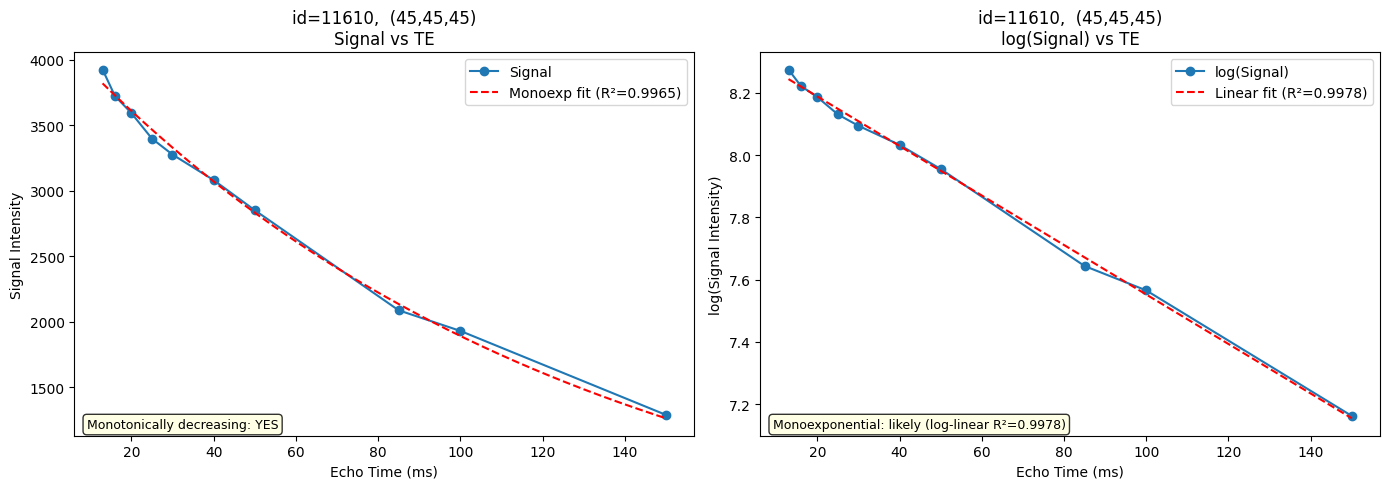

In [9]:
dataset = data.load_dataset(subject_id)
fig = plot_single_voxel_decay(dataset, x=45, y=45, z=45, echo_times=echo_times)
plt.show()

### 3. Plotting the Time-Intensity Curves of Regions of Interest (ROIs)

In [10]:
import time
import pandas as pd


def monoexp(t, S0, R2):
    """Single-component exponential decay model: S(t) = S0 * exp(-R2 * t)."""
    return S0 * np.exp(-t * R2)


def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")


def fit_monoexp(te, signal, log_coeffs=None):
    """Fit monoexponential curve with non-negative parameter constraints."""
    p0 = [max(signal[0], 1e-6), max(-log_coeffs[0], 1e-6) if log_coeffs is not None else 0.01]
    bounds = ([0.0, 0.0], [np.inf, np.inf])
    popt, _ = curve_fit(monoexp, te, signal, p0=p0, bounds=bounds, maxfev=20000)
    yhat = monoexp(te, *popt)
    return popt, yhat


def analyze_voxel_curve(signal, te, mono_r2_threshold=0.99, monotonic_eps_frac=0.01):
    """Analyze one voxel signal for monotonicity and monoexponentiality."""
    signal = np.asarray(signal, dtype=float)
    te = np.asarray(te, dtype=float)

    if len(signal) != len(te) or len(signal) < 3:
        return None

    diffs = np.diff(signal)
    eps = monotonic_eps_frac * max(float(signal[0]), 1.0)
    is_monotonic = bool(np.all(diffs <= eps))
    n_increasing = int(np.sum(diffs > eps))

    positive_mask = signal > 0
    te_pos = te[positive_mask]
    signal_pos = signal[positive_mask]
    if len(te_pos) < 3:
        return None

    log_signal = np.log(signal_pos)
    if len(te_pos) >= 2:
        log_coeffs = np.polyfit(te_pos, log_signal, 1)
        log_fit = np.polyval(log_coeffs, te_pos)
        r2_log = r2_score(log_signal, log_fit)
    else:
        log_coeffs = None
        r2_log = float("nan")

    mono_params = None
    mono_r2 = float("nan")
    try:
        mono_params, mono_yhat = fit_monoexp(te_pos, signal_pos, log_coeffs=log_coeffs)
        mono_r2 = r2_score(signal_pos, mono_yhat)
    except Exception:
        pass

    mono_pass = bool(np.isfinite(mono_r2) and (mono_r2 >= mono_r2_threshold))

    out = {
        "is_monotonic": is_monotonic,
        "n_increasing": n_increasing,
        "r2_log": float(r2_log),
        "mono_r2": float(mono_r2),
        "mono_pass": mono_pass,
    }

    if mono_params is not None:
        out["S0_mono"] = float(mono_params[0])
        out["R2_mono"] = float(mono_params[1])
        out["T2_mono_ms"] = float(1.0 / mono_params[1]) if mono_params[1] > 0 else float("nan")
    else:
        out["S0_mono"] = float("nan")
        out["R2_mono"] = float("nan")
        out["T2_mono_ms"] = float("nan")

    return out


def summarize_segment_voxels(voxel_rows):
    """Aggregate voxel-level metrics for one patient-segment pair."""
    n = len(voxel_rows)
    if n == 0:
        return None

    monotonic_rate = float(np.mean([row["is_monotonic"] for row in voxel_rows]))
    mono_pass_rate = float(np.mean([row["mono_pass"] for row in voxel_rows]))

    t2_vals = np.array([row["T2_mono_ms"] for row in voxel_rows], dtype=float)
    t2_vals = t2_vals[np.isfinite(t2_vals)]

    if len(t2_vals) > 0:
        t2_median = float(np.median(t2_vals))
        t2_iqr = float(np.percentile(t2_vals, 75) - np.percentile(t2_vals, 25))
    else:
        t2_median = float("nan")
        t2_iqr = float("nan")

    return {
        "n_voxels": n,
        "monotonic_rate": monotonic_rate,
        "mono_pass_rate": mono_pass_rate,
        "t2_median_ms": t2_median,
        "t2_iqr_ms": t2_iqr,
    }


def analyze_dataset_by_segment(dataset, echo_times, max_voxels_per_segment=None, random_state=0):
    """Analyze all segments for one patient (segment 0 excluded)."""
    reg = np.asarray(dataset.reg)
    seg = np.asarray(dataset.seg)
    brain_mask = np.asarray(dataset.mask) > 0
    te = np.asarray(echo_times[: reg.shape[3]], dtype=float)
    rng = np.random.default_rng(random_state)

    voxel_rows = []
    segment_rows = []

    for seg_id in range(1, seg.shape[3]):
        segment_mask = (seg[..., seg_id] > 0) & brain_mask
        coords = np.argwhere(segment_mask)
        if len(coords) == 0:
            continue

        if max_voxels_per_segment is not None and len(coords) > max_voxels_per_segment:
            idx = rng.choice(len(coords), size=max_voxels_per_segment, replace=False)
            coords = coords[idx]

        this_segment_voxels = []
        for x, y, z in coords:
            metrics = analyze_voxel_curve(reg[x, y, z, :], te)
            if metrics is None:
                continue

            row = {
                "id": int(dataset.id),
                "segment": int(seg_id),
                "x": int(x),
                "y": int(y),
                "z": int(z),
            }
            row.update(metrics)
            this_segment_voxels.append(row)
            voxel_rows.append(row)

        summary = summarize_segment_voxels(this_segment_voxels)
        if summary is not None:
            summary_row = {"id": int(dataset.id), "segment": int(seg_id)}
            summary_row.update(summary)
            segment_rows.append(summary_row)

    return voxel_rows, segment_rows


def analyze_dataset_by_ids(ids=None, max_patients=None, max_voxels_per_segment=1500, random_state=0):
    """Run patient-level analysis across IDs."""
    if ids is None:
        ids = data.get_ids()
    ids = list(ids)
    if max_patients is not None:
        ids = ids[:max_patients]

    echo_times = data.get_echo_times()
    all_voxel_rows = []
    all_segment_rows = []

    t0 = time.time()
    for i, id_value in enumerate(ids, start=1):
        dataset = data.load_dataset(id_value)
        voxel_rows, segment_rows = analyze_dataset_by_segment(
            dataset,
            echo_times,
            max_voxels_per_segment=max_voxels_per_segment,
            random_state=random_state + i,
        )
        all_voxel_rows.extend(voxel_rows)
        all_segment_rows.extend(segment_rows)
        print(f"[{i}/{len(ids)}] id={id_value}: voxels={len(voxel_rows)}, segment summaries={len(segment_rows)}")

    print(f"Done in {time.time() - t0:.1f}s")
    return all_voxel_rows, all_segment_rows


def cohort_summary_from_segment_rows(segment_rows):
    """Aggregate segment summaries across patients (cohort view)."""
    if len(segment_rows) == 0:
        return []

    out = []
    for seg_id in sorted(set(row["segment"] for row in segment_rows)):
        rows = [row for row in segment_rows if row["segment"] == seg_id]
        finite_t2 = [r["t2_median_ms"] for r in rows if np.isfinite(r["t2_median_ms"])]

        out.append({
            "segment": seg_id,
            "n_patients": len(rows),
            "monotonic_rate_median": float(np.median([r["monotonic_rate"] for r in rows])),
            "mono_pass_rate_median": float(np.median([r["mono_pass_rate"] for r in rows])),
            "t2_median_ms_median": float(np.median(finite_t2)) if len(finite_t2) > 0 else float("nan"),
        })

    return out


def rows_to_df(rows):
    """Convert list-of-dict rows into a DataFrame with stable column ordering."""
    if len(rows) == 0:
        return pd.DataFrame()
    return pd.DataFrame(rows)


def make_patient_segment_matrix(segment_rows, metric):
    ids = sorted(set(row["id"] for row in segment_rows))
    segs = sorted(set(row["segment"] for row in segment_rows))
    mat = np.full((len(ids), len(segs)), np.nan)

    id_to_i = {v: i for i, v in enumerate(ids)}
    seg_to_j = {v: j for j, v in enumerate(segs)}

    for row in segment_rows:
        mat[id_to_i[row["id"]], seg_to_j[row["segment"]]] = row[metric]

    return ids, segs, mat


def plot_patient_segment_heatmap(segment_rows, metric, title, cmap="viridis", vmin=0.0, vmax=1.0):
    ids, segs, mat = make_patient_segment_matrix(segment_rows, metric)
    fig, ax = plt.subplots(figsize=(max(8, len(segs) * 0.6), max(4, len(ids) * 0.4)))

    im = ax.imshow(mat, aspect="auto", interpolation="nearest", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(len(segs)))
    ax.set_xticklabels(segs, rotation=90)
    ax.set_yticks(np.arange(len(ids)))
    ax.set_yticklabels(ids)
    ax.set_xlabel("Segment")
    ax.set_ylabel("Patient ID")
    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(metric)
    plt.tight_layout()
    return fig


def plot_cohort_segment_bars(cohort_rows, metric_key, title, ylabel):
    if len(cohort_rows) == 0:
        print("No cohort rows to plot")
        return None

    segs = [row["segment"] for row in cohort_rows]
    vals = [row[metric_key] for row in cohort_rows]

    fig, ax = plt.subplots(figsize=(max(8, len(segs) * 0.6), 4))
    ax.bar(np.arange(len(segs)), vals)
    ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(len(segs)))
    ax.set_xticklabels(segs, rotation=90)
    ax.set_xlabel("Segment")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.tight_layout()
    return fig

[1/5] id=11610: voxels=7048, segment summaries=5
[2/5] id=13267: voxels=7328, segment summaries=5
[3/5] id=13620: voxels=7499, segment summaries=5
[4/5] id=14121: voxels=7497, segment summaries=5
[5/5] id=14416: voxels=7299, segment summaries=5
Done in 22.2s
Voxel rows: 36671
Patient-segment rows: 25
Cohort-segment rows: 5

voxel_df (head):


,id,segment,x,y,z,is_monotonic,n_increasing,r2_log,mono_r2,mono_pass,S0_mono,R2_mono,T2_mono_ms
0,11610,1,44,36,10,False,1,0.962595,0.946391,False,5003.955923,0.005396,185.330945
1,11610,1,31,58,34,True,0,0.996649,0.995582,True,4284.605623,0.011711,85.386978
2,11610,1,68,35,21,True,0,0.998934,0.997111,True,5745.709579,0.013269,75.364527
3,11610,1,62,71,28,False,2,0.950794,0.964159,False,2066.601034,0.025630,39.016062
4,11610,1,50,58,17,False,1,0.978132,0.962711,False,1985.239348,0.006890,145.128108
5,11610,1,57,43,14,True,0,0.998100,0.998469,True,3356.701710,0.013702,72.980916
6,11610,1,46,22,20,True,0,0.998869,0.997470,True,5241.802269,0.016778,59.600242
7,11610,1,42,23,35,True,0,0.987204,0.983900,False,4007.237742,0.011075,90.296173
8,11610,1,41,41,26,True,0,0.994877,0.995905,True,5139.243333,0.021338,46.865385
9,11610,1,65,49,26,True,0,0.999259,0.997504,True,5752.206580,0.016586,60.290333



patient_segment_df:


,id,segment,n_voxels,monotonic_rate,mono_pass_rate,t2_median_ms,t2_iqr_ms
0,11610,1,1500,0.792667,0.532667,77.366810,34.773753
1,11610,2,1500,0.891333,0.696000,72.015323,22.060785
2,11610,3,1500,0.936667,0.772000,65.216230,15.927862
3,11610,4,1500,0.876000,0.594667,60.203634,22.681903
4,11610,5,1048,0.341603,0.069656,69.421316,42.800093
5,13267,1,1500,0.821333,0.589333,74.295493,20.628898
6,13267,2,1500,0.890667,0.728667,69.569839,14.985418
7,13267,3,1500,0.961333,0.832000,66.017760,12.166559
8,13267,4,1500,0.950667,0.782000,59.389329,16.196961
9,13267,5,1328,0.584337,0.196536,69.475882,23.096444



cohort_df:


,segment,n_patients,monotonic_rate_median,mono_pass_rate_median,t2_median_ms_median
0,1,5,0.760000,0.505333,75.899816
1,2,5,0.890667,0.660440,70.138545
2,3,5,0.936667,0.758000,65.385954
3,4,5,0.912667,0.626667,58.705754
4,5,5,0.462011,0.104139,69.421316


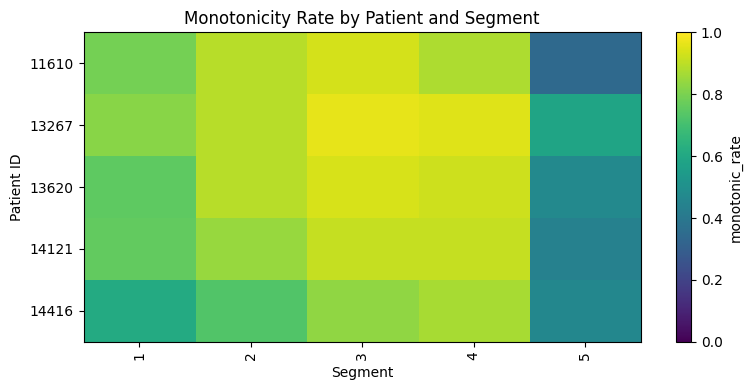

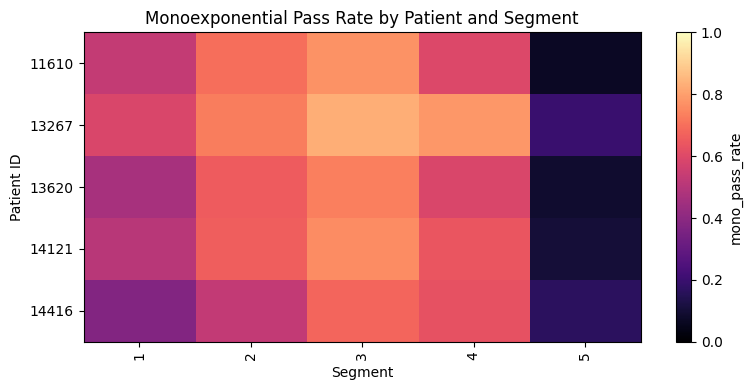

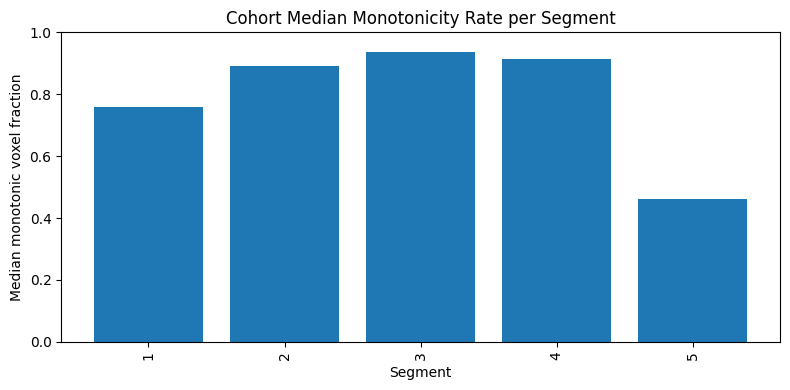

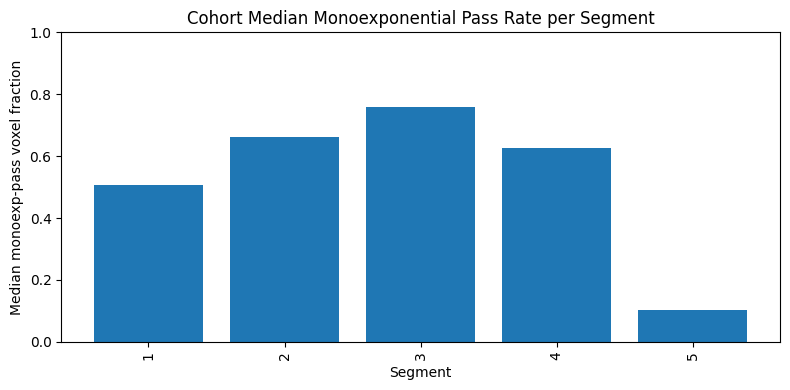

In [11]:
RUN_CONFIG = {
    "ids": data.get_ids(),
    "max_patients": 5,
    "max_voxels_per_segment": 1500,
    "random_state": 42,
}

all_voxel_rows, all_segment_rows = analyze_dataset_by_ids(**RUN_CONFIG)
cohort_rows = cohort_summary_from_segment_rows(all_segment_rows)

# DataFrame-first outputs
voxel_df = rows_to_df(all_voxel_rows)
patient_segment_df = rows_to_df(all_segment_rows)
cohort_df = rows_to_df(cohort_rows)

print(f"Voxel rows: {len(voxel_df)}")
print(f"Patient-segment rows: {len(patient_segment_df)}")
print(f"Cohort-segment rows: {len(cohort_df)}")

print("\nvoxel_df (head):")
display(voxel_df.head(10))

print("\npatient_segment_df:")
display(patient_segment_df.sort_values(["id", "segment"]).reset_index(drop=True))

print("\ncohort_df:")
display(cohort_df.sort_values("segment").reset_index(drop=True))

# Patient-segment heatmaps
plot_patient_segment_heatmap(
    all_segment_rows,
    metric="monotonic_rate",
    title="Monotonicity Rate by Patient and Segment",
    cmap="viridis",
    vmin=0,
    vmax=1,
)
plt.show()

plot_patient_segment_heatmap(
    all_segment_rows,
    metric="mono_pass_rate",
    title="Monoexponential Pass Rate by Patient and Segment",
    cmap="magma",
    vmin=0,
    vmax=1,
)
plt.show()

# Cohort-level bar plots
plot_cohort_segment_bars(
    cohort_rows,
    metric_key="monotonic_rate_median",
    title="Cohort Median Monotonicity Rate per Segment",
    ylabel="Median monotonic voxel fraction",
)
plt.show()

plot_cohort_segment_bars(
    cohort_rows,
    metric_key="mono_pass_rate_median",
    title="Cohort Median Monoexponential Pass Rate per Segment",
    ylabel="Median monoexp-pass voxel fraction",
)
plt.show()

In [12]:
def resolve_echo_axis_for_dataset(dataset, base_echo_times=None):
    """
    Build a robust echo-time axis for the dataset.

    Handles cases where time frames are duplicated relative to base echo times
    (e.g., 20 frames vs a 10-echo protocol).
    """
    if base_echo_times is None:
        base_echo_times = data.get_echo_times()

    n_time = np.asarray(dataset.reg).shape[3]
    base = np.asarray(base_echo_times, dtype=float)

    if len(base) == 0:
        te = np.arange(n_time, dtype=float)
        labels = [f"idx{i}" for i in range(n_time)]
        return te, labels

    if n_time == len(base):
        te = base
        labels = [f"{v:g}" for v in te]
        return te, labels

    if n_time % len(base) == 0:
        repeats = n_time // len(base)
        te = np.tile(base, repeats)
        if repeats > 1:
            labels = [f"{te[i]:g}|rep{i // len(base) + 1}" for i in range(n_time)]
        else:
            labels = [f"{v:g}" for v in te]
        print(
            f"Warning: id={dataset.id} has {n_time} frames; base echo list has {len(base)}. "
            f"Using repeated echo axis ({repeats}x)."
        )
        return te, labels

    # Fallback for irregular lengths.
    te = np.arange(n_time, dtype=float)
    labels = [f"idx{i}" for i in range(n_time)]
    print(
        f"Warning: id={dataset.id} has {n_time} frames that do not match base echo count {len(base)}. "
        f"Using frame index as x-axis."
    )
    return te, labels


def plot_intensity_echo_distribution_for_patient(
    id_value,
    base_echo_times=None,
    max_voxels_per_segment=None,
    random_state=0,
    showfliers=False,
    save_path=None,
):
    """Plot voxel-intensity distributions vs echo for each segmentation in one patient."""
    dataset = data.load_dataset(id_value)
    reg = np.asarray(dataset.reg)
    seg = np.asarray(dataset.seg)
    brain_mask = np.asarray(dataset.mask) > 0
    te, te_labels = resolve_echo_axis_for_dataset(dataset, base_echo_times=base_echo_times)

    rng = np.random.default_rng(random_state)
    seg_ids = [seg_id for seg_id in range(1, seg.shape[3]) if np.any((seg[..., seg_id] > 0) & brain_mask)]

    if len(seg_ids) == 0:
        print(f"No non-empty segments found for id={id_value}")
        return None

    fig, axes = plt.subplots(len(seg_ids), 1, figsize=(max(12, len(te) * 0.8), 3.2 * len(seg_ids)), sharex=True)
    if len(seg_ids) == 1:
        axes = [axes]

    positions = np.arange(len(te))

    for ax, seg_id in zip(axes, seg_ids):
        seg_mask = (seg[..., seg_id] > 0) & brain_mask
        coords = np.argwhere(seg_mask)

        if max_voxels_per_segment is not None and len(coords) > max_voxels_per_segment:
            idx = rng.choice(len(coords), size=max_voxels_per_segment, replace=False)
            coords = coords[idx]

        if len(coords) == 0:
            ax.set_title(f"{format_segment_label(seg_id)}: empty")
            continue

        x, y, z = coords[:, 0], coords[:, 1], coords[:, 2]
        # Matrix shape: (n_voxels, n_time)
        values = reg[x, y, z, :]
        values_by_echo = [values[:, t] for t in range(values.shape[1])]
        means = np.array([v.mean() for v in values_by_echo], dtype=float)

        ax.boxplot(
            values_by_echo,
            positions=positions,
            widths=0.55,
            patch_artist=True,
            showfliers=showfliers,
            medianprops={"color": "black", "linewidth": 1.0},
            boxprops={"facecolor": "#cfe8ff", "edgecolor": "#4a90e2", "linewidth": 0.8},
            whiskerprops={"color": "#4a90e2", "linewidth": 0.8},
            capprops={"color": "#4a90e2", "linewidth": 0.8},
        )
        ax.plot(positions, means, color="#d62728", marker="o", linewidth=1.5, label="Mean")
        ax.set_ylabel("Intensity")
        ax.set_title(f"id={id_value} | {format_segment_label(seg_id)} | n_voxels={len(coords)}")
        ax.grid(alpha=0.2)
        ax.legend(loc="upper right", fontsize=8)

    axes[-1].set_xticks(positions)
    axes[-1].set_xticklabels(te_labels, rotation=60, ha="right")
    axes[-1].set_xlabel("Echo Time (ms)")

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")

    return fig


def plot_intensity_echo_distribution_all_patients(
    ids=None,
    base_echo_times=None,
    max_voxels_per_segment=3000,
    random_state=0,
    showfliers=False,
    save=True,
):
    """Create one distribution plot per patient ID."""
    if ids is None:
        ids = data.get_ids()

    out_dir = output.get_dir("segment_echo_distributions")

    for i, id_value in enumerate(ids, start=1):
        save_path = out_dir / f"{id_value}_echo_distribution.png" if save else None
        fig = plot_intensity_echo_distribution_for_patient(
            id_value,
            base_echo_times=base_echo_times,
            max_voxels_per_segment=max_voxels_per_segment,
            random_state=random_state + i,
            showfliers=showfliers,
            save_path=save_path,
        )
        if fig is not None:
            plt.close(fig)
        print(f"[{i}/{len(ids)}] id={id_value} done")

    print("Finished plotting intensity-vs-echo distributions for all selected patients")

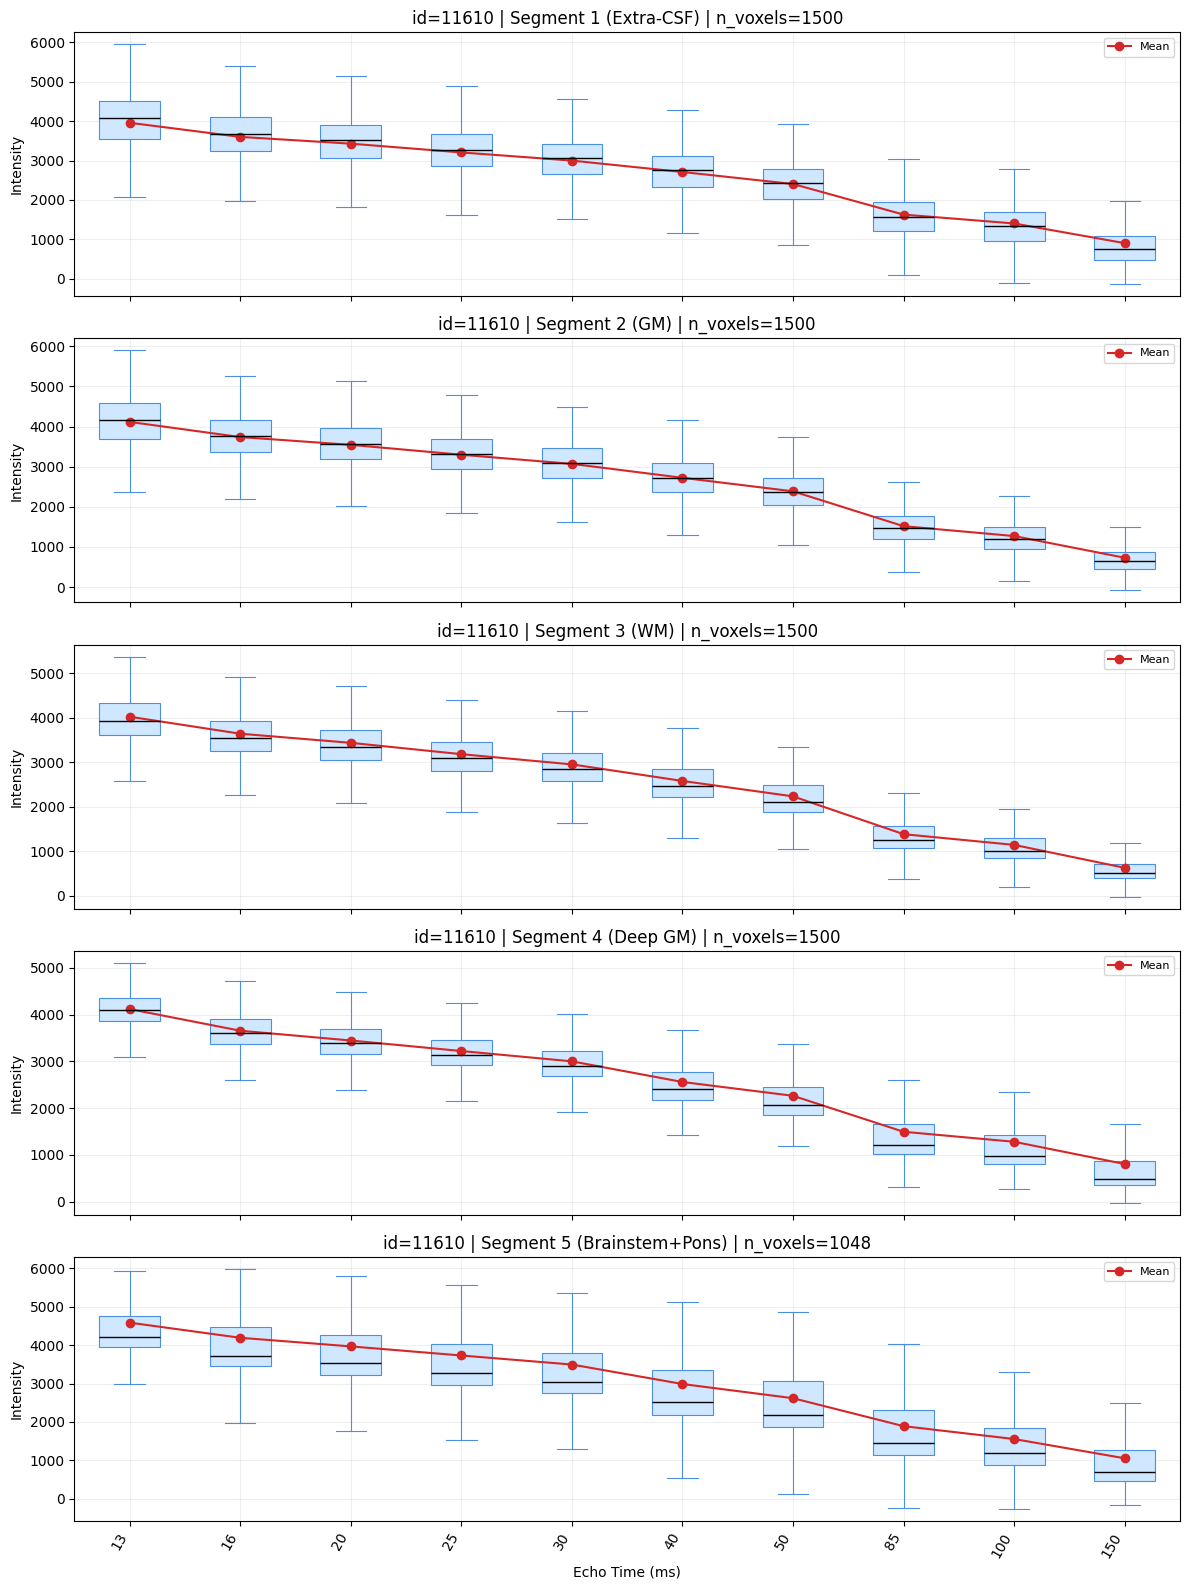

In [13]:
fig = plot_intensity_echo_distribution_for_patient(
    id_value=data.get_ids()[0],
    base_echo_times=data.get_echo_times(),
    max_voxels_per_segment=1500,
    random_state=42,
    showfliers=False,
)
plt.show()

### 4. Performing Checks on Imaging Factors Which May Affect the Time-Intensity Curves

#### 4.1. Masking and Partial Volume Effects

In [14]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.ndimage import (
    binary_dilation,
    binary_erosion,
    center_of_mass,
    distance_transform_edt,
    gaussian_filter,
    )
from scipy.optimize import curve_fit

EPS = 1e-8


def _validate_volume(volume, echo_times):
    volume = np.asarray(volume, dtype=float)
    echo_times = np.asarray(echo_times, dtype=float)
    if volume.ndim != 4:
        raise ValueError("Expected volume with shape (x, y, z, echo).")
    if volume.shape[-1] != echo_times.size:
        raise ValueError("Number of echoes does not match echo_times.")
    return volume, echo_times


def _as_mask(mask, shape):
    if mask is None:
        return np.ones(shape, dtype=bool)
    mask = np.asarray(mask, dtype=bool)
    if mask.shape != shape:
        raise ValueError(f"Mask shape {mask.shape} does not match {shape}.")
    return mask


def _safe_corrcoef(a, b):
    a = np.asarray(a, dtype=float).ravel()
    b = np.asarray(b, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    if not np.any(valid):
        return np.nan
    a = a[valid]
    b = b[valid]
    if a.size < 2:
        return np.nan
    a_std = a.std()
    b_std = b.std()
    if a_std < EPS or b_std < EPS:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])


def _robust_zscore(values):
    values = np.asarray(values, dtype=float)
    median = np.nanmedian(values)
    mad = np.nanmedian(np.abs(values - median))
    scale = 1.4826 * mad
    if not np.isfinite(scale) or scale < EPS:
        return np.full(values.shape, np.nan)
    return (values - median) / scale


def _region_sort_key(region_name):
    if region_name == "brain":
        return (-1, -1)
    if region_name.startswith("segment_"):
        return (0, int(region_name.split("_")[-1]))
    return (1, region_name)


def choose_slice(mask):
    mask = np.asarray(mask, dtype=bool)
    if mask.ndim != 3:
        raise ValueError("Expected a 3D mask.")
    occupancy = mask.sum(axis=(0, 1))
    if occupancy.max() == 0:
        return mask.shape[2] // 2
    return int(np.argmax(occupancy))


def mean_curve(volume, mask):
    volume = np.asarray(volume, dtype=float)
    mask = _as_mask(mask, volume.shape[:-1])
    flat = volume[mask]
    if flat.size == 0:
        return np.full(volume.shape[-1], np.nan)
    return flat.mean(axis=0)


def make_hard_segmentation(segmentation):
    segmentation = np.asarray(segmentation)
    if segmentation.ndim == 3:
        return segmentation
    if segmentation.ndim != 4:
        raise ValueError("Expected segmentation with shape (x, y, z) or (x, y, z, class).")
    return np.argmax(segmentation, axis=-1)


def build_region_masks(segmentation, brain_mask):
    hard_seg = make_hard_segmentation(segmentation)
    brain_mask = _as_mask(brain_mask, hard_seg.shape)
    region_masks = {"brain": brain_mask}

    segment_ids = np.unique(hard_seg)
    segment_ids = segment_ids[segment_ids > 0]
    for seg_id in segment_ids:
        seg_mask = (hard_seg == seg_id) & brain_mask
        if np.any(seg_mask):
            region_masks[f"segment_{int(seg_id)}"] = seg_mask

    return region_masks


def fit_monoexponential(volume, echo_times, mask=None, min_signal=EPS):
    volume, echo_times = _validate_volume(volume, echo_times)
    mask = _as_mask(mask, volume.shape[:-1])

    flat_signal = volume.reshape(-1, volume.shape[-1])
    flat_mask = mask.reshape(-1)
    fit_ok = flat_mask & np.all(np.isfinite(flat_signal), axis=1) & np.all(flat_signal > min_signal, axis=1)

    s0_map = np.full(flat_mask.shape, np.nan)
    t2_map = np.full(flat_mask.shape, np.nan)
    rmse_map = np.full(flat_mask.shape, np.nan)
    r2_map = np.full(flat_mask.shape, np.nan)
    predicted = np.full(flat_signal.shape, np.nan)

    if np.any(fit_ok):
        te = echo_times
        design = np.column_stack([np.ones(te.size), te])
        log_signal = np.log(flat_signal[fit_ok])
        coeffs, _, _, _ = np.linalg.lstsq(design, log_signal.T, rcond=None)
        intercept = coeffs[0]
        slope = coeffs[1]

        pred_log = intercept[:, None] + slope[:, None] * te[None, :]
        pred_signal = np.exp(pred_log)

        s0 = np.exp(intercept)
        t2 = np.full(slope.shape, np.nan)
        valid_t2 = slope < -EPS
        t2[valid_t2] = -1.0 / slope[valid_t2]

        residual = flat_signal[fit_ok] - pred_signal
        ss_res = np.sum(residual ** 2, axis=1)
        centered = flat_signal[fit_ok] - flat_signal[fit_ok].mean(axis=1, keepdims=True)
        ss_tot = np.sum(centered ** 2, axis=1)

        s0_map[fit_ok] = s0
        t2_map[fit_ok] = t2
        rmse_map[fit_ok] = np.sqrt(np.mean(residual ** 2, axis=1))
        r2_map[fit_ok] = np.where(ss_tot > EPS, 1.0 - ss_res / ss_tot, np.nan)
        predicted[fit_ok] = pred_signal

    spatial_shape = volume.shape[:-1]
    return {
        "s0_map": s0_map.reshape(spatial_shape),
        "t2_map": t2_map.reshape(spatial_shape),
        "rmse_map": rmse_map.reshape(spatial_shape),
        "r2_map": r2_map.reshape(spatial_shape),
        "predicted": predicted.reshape(volume.shape),
        "mask": mask,
        "echo_times": echo_times,
    }


def plot_fit_maps(fit_result, slice_index=None, title_prefix=""):
    mask = fit_result["mask"]
    slice_index = choose_slice(mask) if slice_index is None else slice_index

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    maps = [
        ("T2", fit_result["t2_map"][..., slice_index]),
        ("RMSE", fit_result["rmse_map"][..., slice_index]),
        ("R2", fit_result["r2_map"][..., slice_index]),
    ]
    for ax, (title, image) in zip(axes, maps):
        shown = np.where(mask[..., slice_index], image, np.nan)
        im = ax.imshow(shown.T, origin="lower", cmap="viridis")
        full_title = f"{title_prefix} {title} z={slice_index}".strip()
        ax.set_title(full_title)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    return fig


def plot_fit_maps_by_region(volume, echo_times, region_masks):
    fit_by_region = {}
    for region_name in sorted(region_masks.keys(), key=_region_sort_key):
        region_mask = region_masks[region_name]
        fit_by_region[region_name] = fit_monoexponential(volume, echo_times, mask=region_mask)
        plot_fit_maps(fit_by_region[region_name], title_prefix=region_name)
        plt.show()
    return fit_by_region

In [15]:
def plot_segmentation_overlay(volume, segmentation, mask=None, slice_index=None, echo_index=0, alpha=0.35, title_prefix=""):
    volume = np.asarray(volume, dtype=float)
    labels = make_hard_segmentation(segmentation)
    if volume.ndim != 4:
        raise ValueError("Expected volume with shape (x, y, z, echo).")
    if labels.shape != volume.shape[:-1]:
        raise ValueError("Segmentation shape does not match volume shape.")

    if mask is None:
        mask = np.ones(labels.shape, dtype=bool)
    else:
        mask = _as_mask(mask, labels.shape)
    slice_index = choose_slice(mask) if slice_index is None else slice_index

    fig, ax = plt.subplots(figsize=(6, 6))
    base = volume[..., slice_index, echo_index]
    overlay = np.where(mask[..., slice_index], labels[..., slice_index], np.nan)
    ax.imshow(base.T, origin="lower", cmap="gray")
    ax.imshow(overlay.T, origin="lower", cmap="tab20", alpha=alpha)
    ax.set_title(f"{title_prefix} Segmentation overlay z={slice_index}, echo={echo_index}".strip())
    ax.axis("off")
    fig.tight_layout()
    return fig


def plot_region_overlays(volume, segmentation, region_masks, slice_index=None, echo_index=0, alpha=0.35):
    volume = np.asarray(volume, dtype=float)
    labels = make_hard_segmentation(segmentation)
    region_names = sorted(region_masks.keys(), key=_region_sort_key)

    if slice_index is None:
        slice_index = choose_slice(region_masks["brain"]) if "brain" in region_masks else choose_slice(next(iter(region_masks.values())))

    n_regions = len(region_names)
    n_cols = min(4, n_regions)
    n_rows = int(np.ceil(n_regions / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    base = volume[..., slice_index, echo_index]
    for i, region_name in enumerate(region_names):
        ax = axes[i]
        region_mask = _as_mask(region_masks[region_name], labels.shape)
        overlay = np.where(region_mask[..., slice_index], labels[..., slice_index], np.nan)
        ax.imshow(base.T, origin="lower", cmap="gray")
        ax.imshow(overlay.T, origin="lower", cmap="tab20", alpha=alpha)
        ax.set_title(region_name)
        ax.axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"All regions overlay (z={slice_index}, echo={echo_index})", y=1.02)
    fig.tight_layout()
    return fig


def check_masking_and_partial_volume(volume, echo_times, mask, erosion_iters=(1, 2), distance_bins=(0, 1, 2, 3, 5, 8)):
    fit = fit_monoexponential(volume, echo_times, mask=mask)
    t2_map = fit["t2_map"]
    mask = fit["mask"]

    distances = distance_transform_edt(mask)
    eroded_summaries = []
    base_values = t2_map[mask]
    base_mean = float(np.nanmean(base_values))
    base_median = float(np.nanmedian(base_values))

    eroded_summaries.append(
        {
            "label": "full_mask",
            "voxels": int(mask.sum()),
            "mean_t2": base_mean,
            "median_t2": base_median,
        }
    )

    for iteration in erosion_iters:
        eroded = binary_erosion(mask, iterations=iteration)
        values = t2_map[eroded]
        eroded_summaries.append(
            {
                "label": f"eroded_{iteration}",
                "voxels": int(eroded.sum()),
                "mean_t2": float(np.nanmean(values)) if values.size else np.nan,
                "median_t2": float(np.nanmedian(values)) if values.size else np.nan,
            }
        )

    distance_stats = []
    edges = list(distance_bins) + [np.inf]
    for lower, upper in zip(edges[:-1], edges[1:]):
        shell = mask & (distances > lower) & (distances <= upper)
        values = t2_map[shell]
        distance_stats.append(
            {
                "distance_min": float(lower),
                "distance_max": float(upper),
                "voxels": int(shell.sum()),
                "mean_t2": float(np.nanmean(values)) if values.size else np.nan,
                "median_t2": float(np.nanmedian(values)) if values.size else np.nan,
                "std_t2": float(np.nanstd(values)) if values.size else np.nan,
            }
        )

    edge_shell = mask & (distances <= 1.5)
    return {
        "fit": fit,
        "mask": mask,
        "edge_shell": edge_shell,
        "distance_map": distances,
        "erosion_summary": eroded_summaries,
        "distance_summary": distance_stats,
    }


def plot_masking_and_partial_volume(summary, slice_index=None, title_prefix=""):
    mask = summary["mask"]
    t2_map = summary["fit"]["t2_map"]
    edge_shell = summary["edge_shell"]
    slice_index = choose_slice(mask) if slice_index is None else slice_index

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].imshow(mask[..., slice_index].T, origin="lower", cmap="gray")
    axes[0].set_title(f"{title_prefix} Mask z={slice_index}".strip())
    axes[0].axis("off")

    axes[1].imshow(mask[..., slice_index].T, origin="lower", cmap="gray")
    axes[1].imshow(np.where(edge_shell[..., slice_index], 1.0, np.nan).T, origin="lower", cmap="autumn", alpha=0.7)
    axes[1].set_title(f"{title_prefix} Boundary shell".strip())
    axes[1].axis("off")

    shown = np.where(mask[..., slice_index], t2_map[..., slice_index], np.nan)
    im = axes[2].imshow(shown.T, origin="lower", cmap="viridis")
    axes[2].set_title(f"{title_prefix} T2 map".strip())
    axes[2].axis("off")
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    fig.tight_layout()
    return fig


def plot_masking_partial_volume_all_regions(summary_by_region):
    region_names = sorted(summary_by_region.keys(), key=_region_sort_key)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for region_name in region_names:
        summary = summary_by_region[region_name]
        labels = [item["label"] for item in summary["erosion_summary"]]
        medians = [item["median_t2"] for item in summary["erosion_summary"]]
        axes[0].plot(labels, medians, marker="o", label=region_name)
    axes[0].set_ylabel("Median T2")
    axes[0].set_title("Erosion sensitivity by region (median)")
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].legend(fontsize=8, ncol=2)

    for region_name in region_names:
        summary = summary_by_region[region_name]
        distance_mid = []
        distance_median = []
        for item in summary["distance_summary"]:
            upper = item["distance_max"]
            upper = item["distance_min"] + 1 if not np.isfinite(upper) else upper
            distance_mid.append(0.5 * (item["distance_min"] + upper))
            distance_median.append(item["median_t2"])
        axes[1].plot(distance_mid, distance_median, marker="o", label=region_name)
    axes[1].set_xlabel("Distance from mask boundary (voxels)")
    axes[1].set_ylabel("Median T2")
    axes[1].set_title("Boundary-distance trend by region (median)")
    axes[1].legend(fontsize=8, ncol=2)
    fig.tight_layout()
    return fig


def run_masking_partial_volume_by_region(volume, echo_times, segmentation, region_masks, show_per_region=False):
    summary_by_region = {}
    region_names = sorted(region_masks.keys(), key=_region_sort_key)
    for region_name in region_names:
        region_mask = region_masks[region_name]
        summary_by_region[region_name] = check_masking_and_partial_volume(volume, echo_times, region_mask)
        if show_per_region:
            plot_masking_and_partial_volume(summary_by_region[region_name], title_prefix=region_name)
            plt.show()

    plot_region_overlays(volume, segmentation, region_masks)
    plt.show()
    plot_masking_partial_volume_all_regions(summary_by_region)
    plt.show()
    return summary_by_region

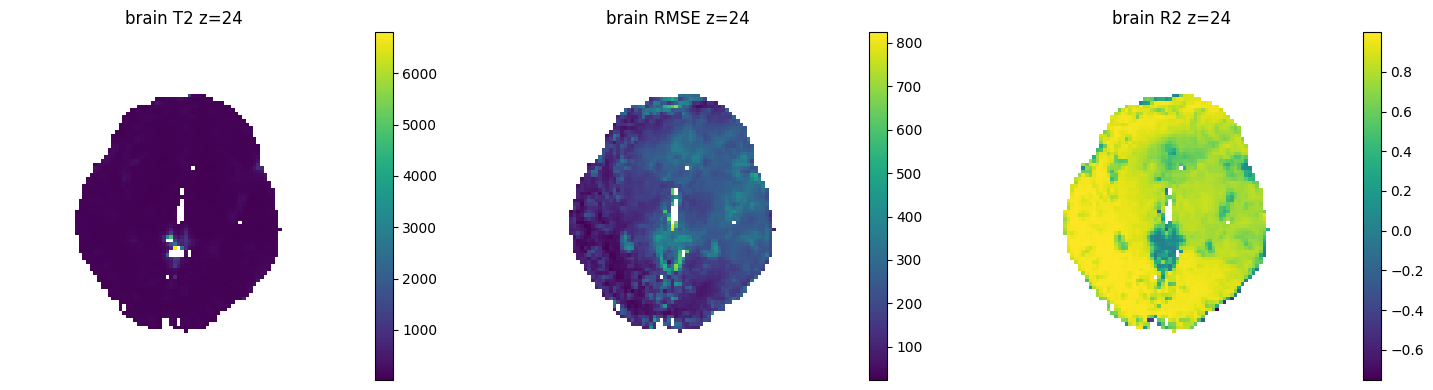

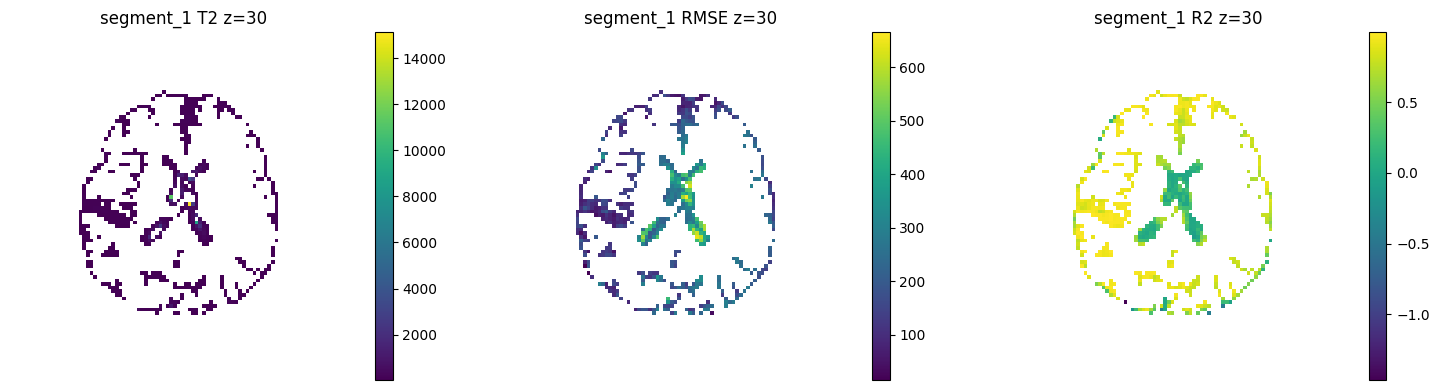

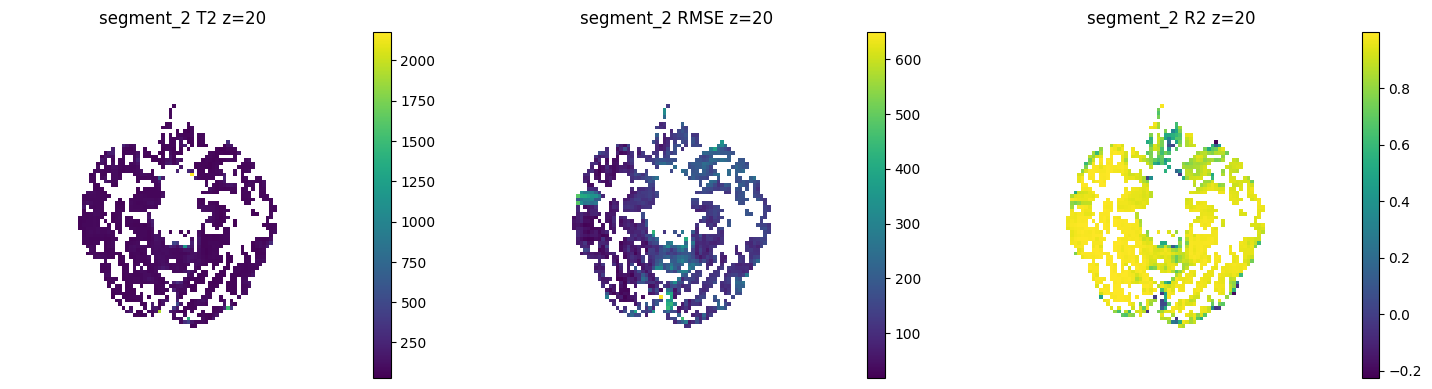

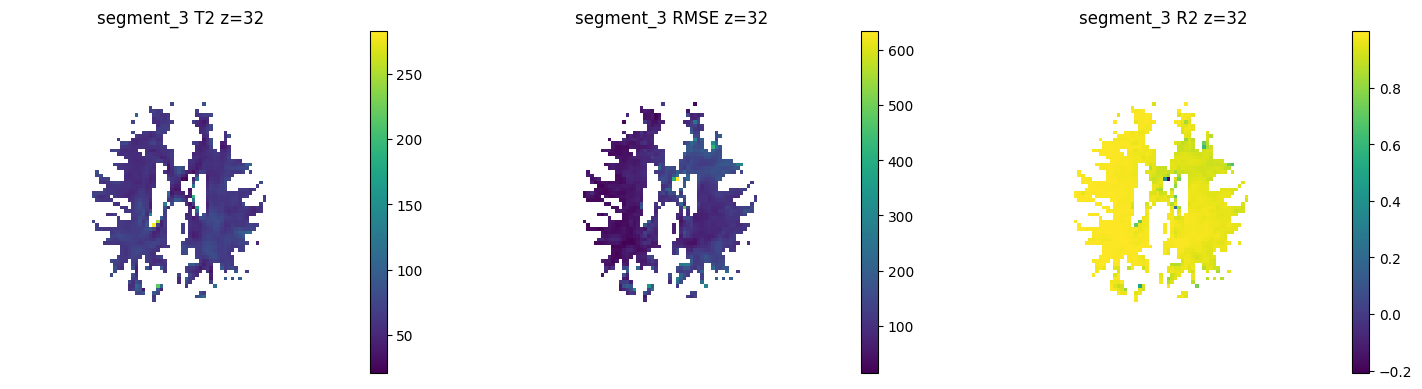

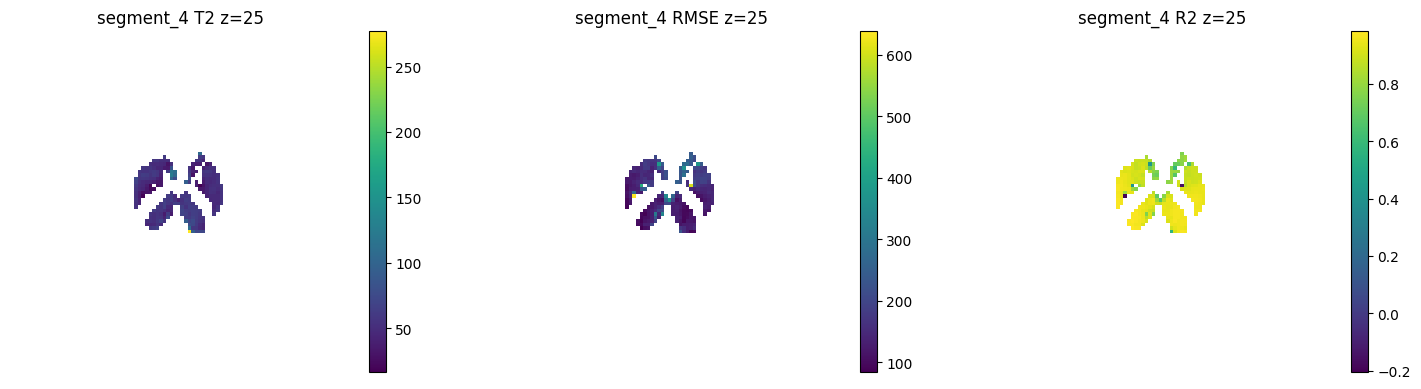

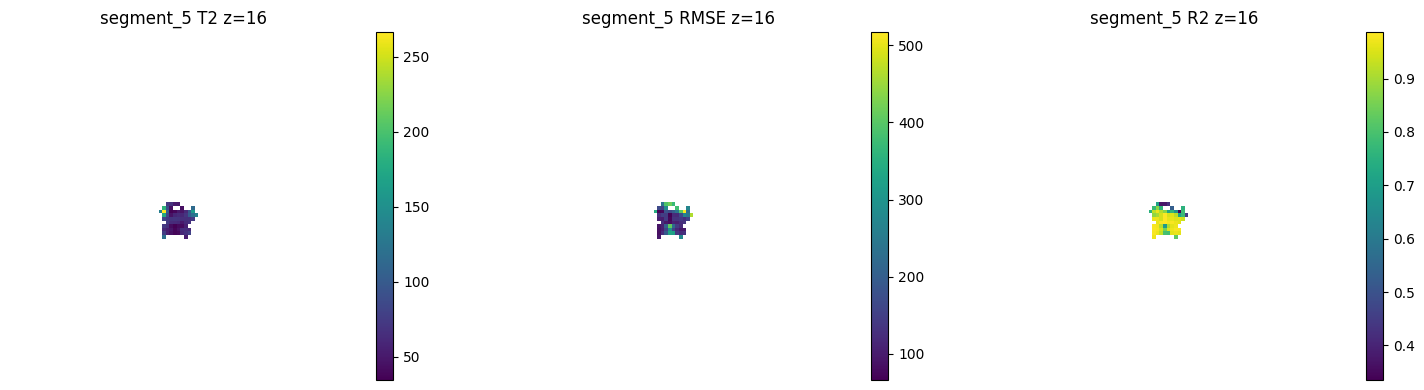

In [16]:
import numpy as np
import data

dataset = data.load_dataset(17065)
volume = np.asarray(dataset.reg, dtype=float)
brain_mask = np.asarray(dataset.mask) > 0
echo_times = np.asarray(data.get_echo_times()[: volume.shape[-1]], dtype=float)

region_masks = build_region_masks(dataset.seg, brain_mask)
fit_by_region = plot_fit_maps_by_region(volume, echo_times, region_masks)

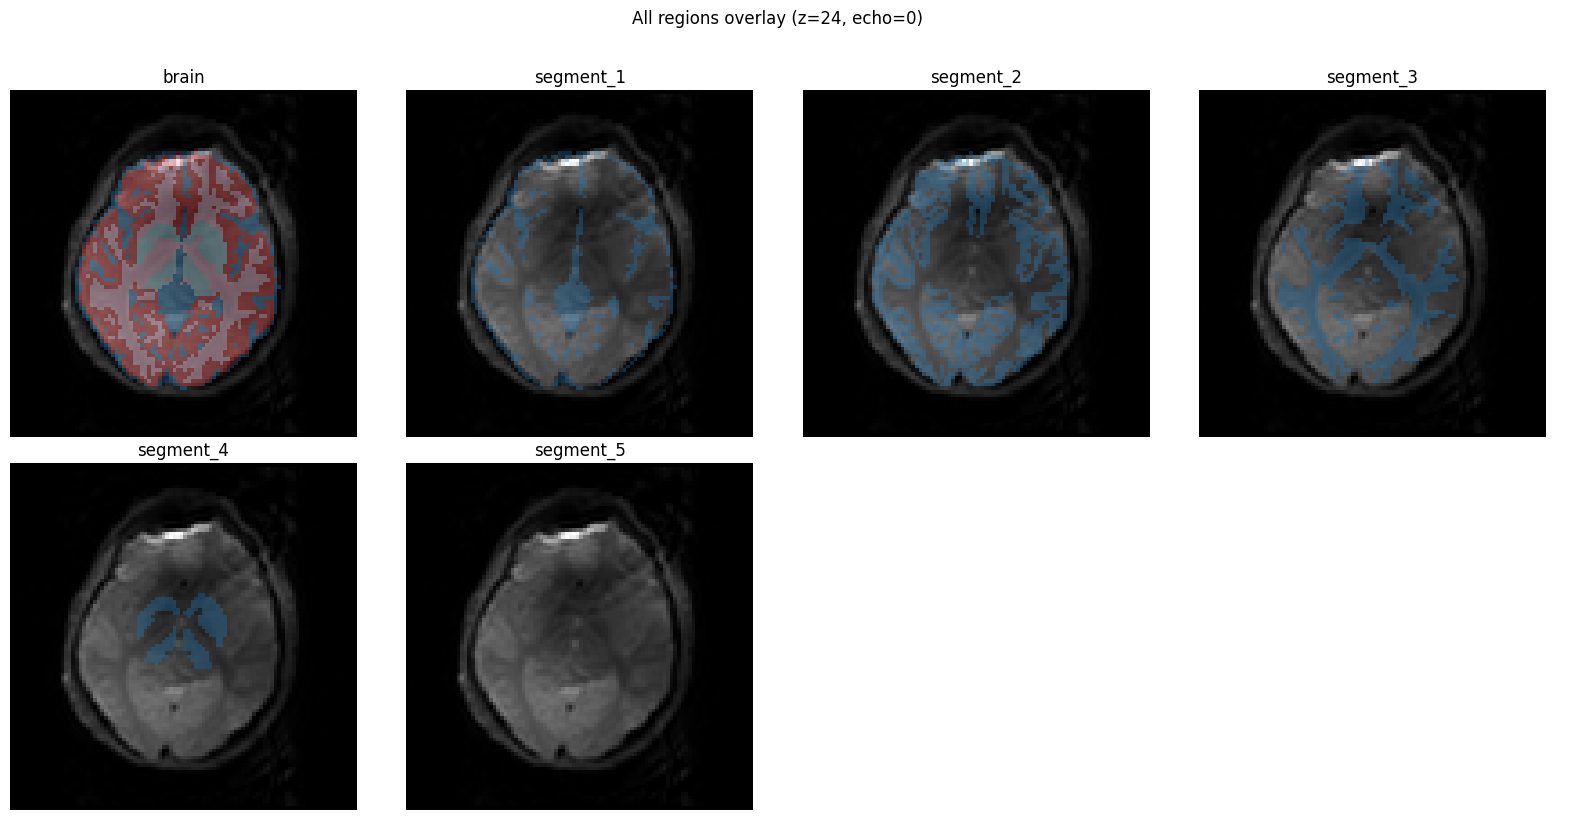

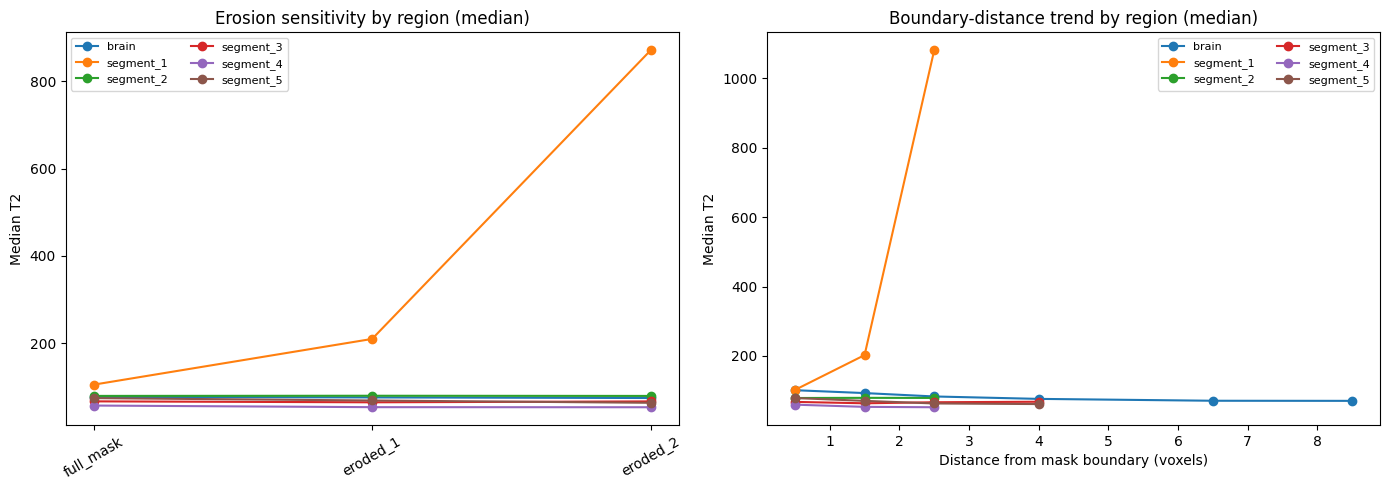

,region,voxels,mean_t2_full,median_t2_full
0,brain,76461,158.953763,76.658767
1,segment_1,19025,348.247691,104.729578
2,segment_2,33811,117.115245,78.992275
3,segment_3,20942,78.345428,66.508758
4,segment_4,1879,69.444859,56.898788
5,segment_5,804,153.480578,73.922573


In [17]:
import pandas as pd

masking_results = run_masking_partial_volume_by_region(
    volume=volume,
    echo_times=echo_times,
    segmentation=dataset.seg,
    region_masks=region_masks,
    show_per_region=False,
    )

masking_summary_rows = []
for region_name, summary in masking_results.items():
    full_entry = next(item for item in summary["erosion_summary"] if item["label"] == "full_mask")
    masking_summary_rows.append({
        "region": region_name,
        "voxels": full_entry["voxels"],
        "mean_t2_full": full_entry["mean_t2"],
        "median_t2_full": full_entry["median_t2"],
    })

display(pd.DataFrame(masking_summary_rows).sort_values("region").reset_index(drop=True))

#### 4.2. Noise Floor and Signal-to-Noise Ratio (SNR)

In [18]:
def fit_mean_curve(curve, echo_times):
    curve = np.asarray(curve, dtype=float)
    echo_times = np.asarray(echo_times, dtype=float)
    valid = np.isfinite(curve) & (curve > EPS)
    if valid.sum() < 2:
        return {
            "s0": np.nan,
            "t2": np.nan,
            "rmse": np.nan,
            "r2": np.nan,
            "predicted": np.full(curve.shape, np.nan),
        }

    te = echo_times[valid]
    y = np.log(curve[valid])
    design = np.column_stack([np.ones(te.size), te])
    intercept, slope = np.linalg.lstsq(design, y, rcond=None)[0]

    predicted = np.exp(intercept + slope * echo_times)
    residual = curve - predicted
    ss_res = np.sum(residual[valid] ** 2)
    ss_tot = np.sum((curve[valid] - curve[valid].mean()) ** 2)

    t2 = np.nan
    if slope < -EPS:
        t2 = -1.0 / slope

    return {
        "s0": float(np.exp(intercept)),
        "t2": float(t2),
        "rmse": float(np.sqrt(np.mean(residual[valid] ** 2))),
        "r2": float(1.0 - ss_res / ss_tot) if ss_tot > EPS else np.nan,
        "predicted": predicted,
    }


def fit_mean_curve_with_offset(curve, echo_times):
    curve = np.asarray(curve, dtype=float)
    echo_times = np.asarray(echo_times, dtype=float)
    valid = np.isfinite(curve) & (curve > -EPS)
    if valid.sum() < 3:
        return {
            "s0": np.nan,
            "t2": np.nan,
            "offset": np.nan,
            "rmse": np.nan,
            "predicted": np.full(curve.shape, np.nan),
        }

    te = echo_times[valid]
    y = curve[valid]

    def model(te_vals, s0, t2, offset):
        return s0 * np.exp(-te_vals / t2) + offset

    p0 = [max(float(y.max() - y.min()), EPS), max(float(np.median(te)), EPS), max(float(y.min()), 0.0)]
    bounds = ([0.0, EPS, 0.0], [np.inf, np.inf, np.inf])
    params, _ = curve_fit(model, te, y, p0=p0, bounds=bounds, maxfev=10000)

    predicted = model(echo_times, *params)
    residual = curve - predicted
    return {
        "s0": float(params[0]),
        "t2": float(params[1]),
        "offset": float(params[2]),
        "rmse": float(np.sqrt(np.mean(residual[valid] ** 2))),
        "predicted": predicted,
    }


def estimate_background_mask(volume, brain_mask, dilation_iters=3, first_echo_percentile=20):
    volume = np.asarray(volume, dtype=float)
    brain_mask = _as_mask(brain_mask, volume.shape[:-1])
    outside = ~binary_dilation(brain_mask, iterations=dilation_iters)
    candidates = volume[..., 0][outside]
    if candidates.size == 0:
        return outside
    cutoff = np.percentile(candidates, first_echo_percentile)
    return outside & (volume[..., 0] <= cutoff)


def check_noise_floor(volume, echo_times, mask, tail_echoes=2, dilation_iters=3):
    volume, echo_times = _validate_volume(volume, echo_times)
    mask = _as_mask(mask, volume.shape[:-1])
    background_mask = estimate_background_mask(volume, mask, dilation_iters=dilation_iters)

    foreground_curve = mean_curve(volume, mask)
    background_curve = mean_curve(volume, background_mask)
    background_std_curve = np.full(echo_times.shape, np.nan)
    if np.any(background_mask):
        background_vals = volume[background_mask]
        background_std_curve = np.nanstd(background_vals, axis=0)

    full_fit = fit_mean_curve(foreground_curve, echo_times)
    offset_fit = fit_mean_curve_with_offset(foreground_curve, echo_times)

    no_tail_fit = None
    if tail_echoes > 0 and tail_echoes < echo_times.size:
        no_tail_fit = fit_mean_curve(foreground_curve[:-tail_echoes], echo_times[:-tail_echoes])

    snr_curve = foreground_curve / np.maximum(background_std_curve, EPS)
    return {
        "foreground_curve": foreground_curve,
        "background_curve": background_curve,
        "background_std_curve": background_std_curve,
        "background_mask": background_mask,
        "snr_curve": snr_curve,
        "full_fit": full_fit,
        "offset_fit": offset_fit,
        "tail_dropped_fit": no_tail_fit,
        "tail_echoes": tail_echoes,
    }


def plot_noise_floor(summary, echo_times, title_prefix=""):
    echo_times = np.asarray(echo_times, dtype=float)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    fg = summary["foreground_curve"]
    bg = summary["background_curve"]
    axes[0].semilogy(echo_times, fg, marker="o", label="region")
    axes[0].semilogy(echo_times, bg, marker="o", label="background")

    full_pred = summary["full_fit"]["predicted"]
    axes[0].semilogy(echo_times, full_pred, linestyle="--", label="mono-exp fit")

    offset_pred = summary["offset_fit"]["predicted"]
    axes[0].semilogy(echo_times, offset_pred, linestyle=":", label="fit + offset")
    axes[0].set_xlabel("TE")
    axes[0].set_ylabel("Signal")
    axes[0].set_title(f"{title_prefix} Noise-floor check".strip())
    axes[0].legend()

    axes[1].plot(echo_times, summary["snr_curve"], marker="o")
    axes[1].set_xlabel("TE")
    axes[1].set_ylabel("Region / background std")
    axes[1].set_title(f"{title_prefix} SNR estimate".strip())
    fig.tight_layout()
    return fig


def plot_noise_floor_all_regions(summary_by_region, echo_times):
    region_names = sorted(summary_by_region.keys(), key=_region_sort_key)
    echo_times = np.asarray(echo_times, dtype=float)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    for region_name in region_names:
        summary = summary_by_region[region_name]
        axes[0].semilogy(echo_times, summary["foreground_curve"], marker="o", linewidth=1.2, label=region_name)
    axes[0].set_xlabel("TE")
    axes[0].set_ylabel("Mean signal")
    axes[0].set_title("Foreground decay by region")
    axes[0].legend(fontsize=8, ncol=2)

    for region_name in region_names:
        summary = summary_by_region[region_name]
        axes[1].plot(echo_times, summary["snr_curve"], marker="o", linewidth=1.2, label=region_name)
    axes[1].set_xlabel("TE")
    axes[1].set_ylabel("Region / background std")
    axes[1].set_title("SNR estimate")
    axes[1].legend(fontsize=8, ncol=2)

    x = np.arange(len(region_names))
    full_t2 = [summary_by_region[name]["full_fit"]["t2"] for name in region_names]
    offset_t2 = [summary_by_region[name]["offset_fit"]["t2"] for name in region_names]
    width = 0.4
    axes[2].bar(x - width / 2, full_t2, width=width, label="mono-exp")
    axes[2].bar(x + width / 2, offset_t2, width=width, label="exp + offset")
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(region_names, rotation=45, ha="right")
    axes[2].set_ylabel("Estimated T2")
    axes[2].set_title("T2 sensitivity to offset model")
    axes[2].legend()

    fig.tight_layout()
    return fig


def run_noise_floor_by_region(volume, echo_times, region_masks, tail_echoes=2, show_per_region=False):
    summary_by_region = {}
    for region_name in sorted(region_masks.keys(), key=_region_sort_key):
        region_mask = region_masks[region_name]
        summary = check_noise_floor(volume, echo_times, region_mask, tail_echoes=tail_echoes)
        summary_by_region[region_name] = summary
        if show_per_region:
            plot_noise_floor(summary, echo_times, title_prefix=region_name)
            plt.show()

    plot_noise_floor_all_regions(summary_by_region, echo_times)
    plt.show()
    return summary_by_region

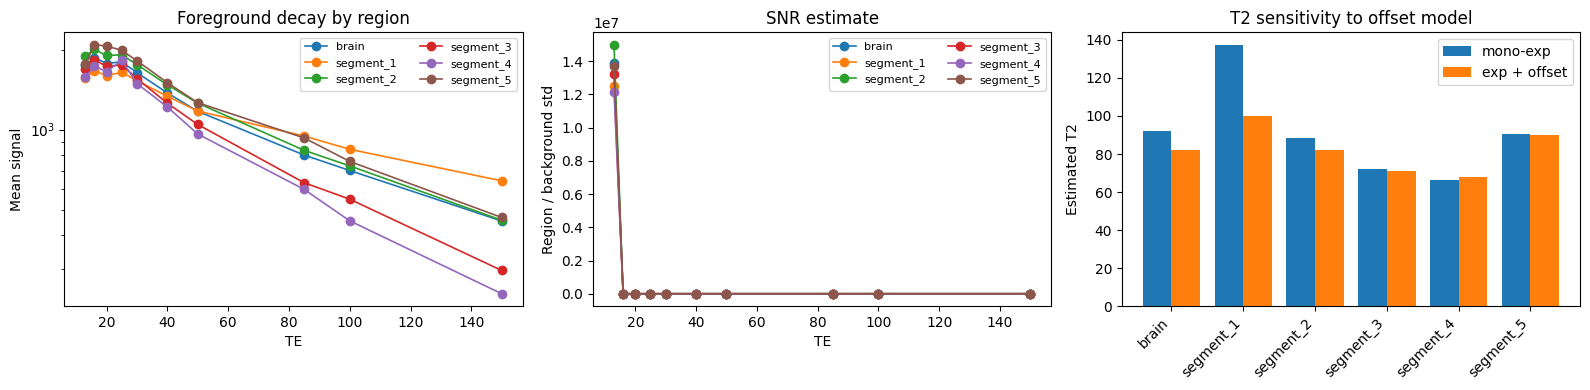

,region,t2_mono,t2_with_offset,offset,rmse_mono,rmse_with_offset
0,brain,92.316529,82.252625,7.870577e+01,79.319243,77.247424
1,segment_1,137.110869,99.775441,2.632772e+02,66.287767,63.335200
2,segment_2,88.425301,82.346706,4.487992e+01,76.522656,74.999235
3,segment_3,72.236992,71.115406,7.077384e-14,89.696139,89.074089
4,segment_4,66.125998,68.058834,1.220143e-12,130.148999,129.575871
5,segment_5,90.282078,89.930945,4.843438e-11,133.880102,133.660965


In [19]:
# 2. Noise floor by region
noise_results = run_noise_floor_by_region(
    volume=volume,
    echo_times=echo_times,
    region_masks=region_masks,
    tail_echoes=2,
    show_per_region=False,
    )

noise_summary_rows = []
for region_name, summary in noise_results.items():
    noise_summary_rows.append({
        "region": region_name,
        "t2_mono": summary["full_fit"]["t2"],
        "t2_with_offset": summary["offset_fit"]["t2"],
        "offset": summary["offset_fit"]["offset"],
        "rmse_mono": summary["full_fit"]["rmse"],
        "rmse_with_offset": summary["offset_fit"]["rmse"],
    })

display(pd.DataFrame(noise_summary_rows).sort_values("region").reset_index(drop=True))

#### 4.3. Imperfect Registration

In [20]:
def check_registration(volume, mask=None, reference_echo=0):
    volume = np.asarray(volume, dtype=float)
    mask = _as_mask(mask, volume.shape[:-1]) if mask is not None else np.ones(volume.shape[:-1], dtype=bool)

    reference = volume[..., reference_echo]
    weighted_reference = np.clip(reference, 0.0, None) * mask
    com_reference = np.asarray(center_of_mass(weighted_reference))

    correlations = []
    rms_diff = []
    com_shifts = []

    ref_vals = reference[mask]
    for echo_index in range(volume.shape[-1]):
        current = volume[..., echo_index]
        correlations.append(_safe_corrcoef(ref_vals, current[mask]))
        rms_diff.append(float(np.sqrt(np.mean((current[mask] - ref_vals) ** 2))))
        weighted = np.clip(current, 0.0, None) * mask
        com_current = np.asarray(center_of_mass(weighted))
        com_shifts.append(float(np.linalg.norm(com_current - com_reference)))

    return {
        "reference_echo": reference_echo,
        "correlation_to_reference": np.asarray(correlations),
        "rms_difference_to_reference": np.asarray(rms_diff),
        "center_of_mass_shift": np.asarray(com_shifts),
    }


def plot_registration(metrics, echo_times, title_prefix=""):
    echo_times = np.asarray(echo_times, dtype=float)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(echo_times, metrics["correlation_to_reference"], marker="o")
    axes[0].set_title(f"{title_prefix} Correlation to reference".strip())
    axes[0].set_xlabel("TE")
    axes[0].set_ylabel("Correlation")

    axes[1].plot(echo_times, metrics["rms_difference_to_reference"], marker="o")
    axes[1].set_title(f"{title_prefix} RMS to reference".strip())
    axes[1].set_xlabel("TE")
    axes[1].set_ylabel("RMS difference")

    axes[2].plot(echo_times, metrics["center_of_mass_shift"], marker="o")
    axes[2].set_title(f"{title_prefix} Center-of-mass shift".strip())
    axes[2].set_xlabel("TE")
    axes[2].set_ylabel("Shift (voxels)")
    fig.tight_layout()
    return fig


def plot_registration_all_regions(summary_by_region, echo_times):
    region_names = sorted(summary_by_region.keys(), key=_region_sort_key)
    echo_times = np.asarray(echo_times, dtype=float)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    for region_name in region_names:
        metrics = summary_by_region[region_name]
        axes[0].plot(echo_times, metrics["correlation_to_reference"], marker="o", linewidth=1.2, label=region_name)
    axes[0].set_title("Correlation to reference by region")
    axes[0].set_xlabel("TE")
    axes[0].set_ylabel("Correlation")
    axes[0].legend(fontsize=8, ncol=2)

    for region_name in region_names:
        metrics = summary_by_region[region_name]
        axes[1].plot(echo_times, metrics["rms_difference_to_reference"], marker="o", linewidth=1.2, label=region_name)
    axes[1].set_title("RMS difference to reference")
    axes[1].set_xlabel("TE")
    axes[1].set_ylabel("RMS difference")
    axes[1].legend(fontsize=8, ncol=2)

    for region_name in region_names:
        metrics = summary_by_region[region_name]
        axes[2].plot(echo_times, metrics["center_of_mass_shift"], marker="o", linewidth=1.2, label=region_name)
    axes[2].set_title("Center-of-mass shift by region")
    axes[2].set_xlabel("TE")
    axes[2].set_ylabel("Shift (voxels)")
    axes[2].legend(fontsize=8, ncol=2)

    fig.tight_layout()
    return fig


def run_registration_by_region(volume, echo_times, region_masks, reference_echo=0, show_per_region=False):
    summary_by_region = {}
    for region_name in sorted(region_masks.keys(), key=_region_sort_key):
        region_mask = region_masks[region_name]
        summary = check_registration(volume, mask=region_mask, reference_echo=reference_echo)
        summary_by_region[region_name] = summary
        if show_per_region:
            plot_registration(summary, echo_times, title_prefix=region_name)
            plt.show()

    plot_registration_all_regions(summary_by_region, echo_times)
    plt.show()
    return summary_by_region

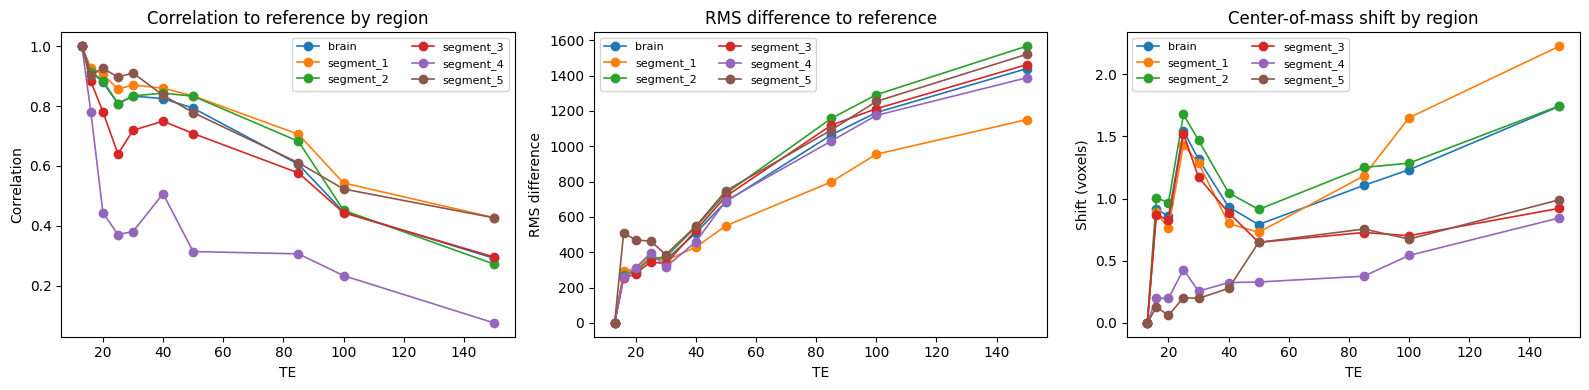

,region,corr_last_echo,rms_last_echo,max_com_shift
0,brain,0.291215,1439.647921,1.741973
1,segment_1,0.427195,1150.871425,2.224958
2,segment_2,0.271947,1566.941585,1.744981
3,segment_3,0.295478,1462.266146,1.521539
4,segment_4,0.075286,1387.821058,0.844223
5,segment_5,0.426444,1520.693691,0.990290


In [21]:
registration_results = run_registration_by_region(
    volume=volume,
    echo_times=echo_times,
    region_masks=region_masks,
    reference_echo=0,
    show_per_region=False,
    )

registration_summary_rows = []
for region_name, summary in registration_results.items():
    registration_summary_rows.append({
        "region": region_name,
        "corr_last_echo": summary["correlation_to_reference"][-1],
        "rms_last_echo": summary["rms_difference_to_reference"][-1],
        "max_com_shift": np.nanmax(summary["center_of_mass_shift"]),
    })

display(pd.DataFrame(registration_summary_rows).sort_values("region").reset_index(drop=True))

#### 4.4. Motion Between Echoes

In [22]:
def check_motion_between_echoes(volume, mask):
    volume = np.asarray(volume, dtype=float)
    mask = _as_mask(mask, volume.shape[:-1])

    successive_corr = []
    successive_rms = []
    successive_com = []

    global_curve = mean_curve(volume, mask)
    log_curve = np.log(np.clip(global_curve, EPS, None))
    curvature = np.full(global_curve.shape, np.nan)
    if global_curve.size >= 3:
        curvature[1:-1] = log_curve[:-2] - 2 * log_curve[1:-1] + log_curve[2:]

    for echo_index in range(1, volume.shape[-1]):
        previous = volume[..., echo_index - 1]
        current = volume[..., echo_index]
        successive_corr.append(_safe_corrcoef(previous[mask], current[mask]))
        successive_rms.append(float(np.sqrt(np.mean((current[mask] - previous[mask]) ** 2))))
        com_prev = np.asarray(center_of_mass(np.clip(previous, 0.0, None) * mask))
        com_curr = np.asarray(center_of_mass(np.clip(current, 0.0, None) * mask))
        successive_com.append(float(np.linalg.norm(com_curr - com_prev)))

    successive_corr = np.asarray(successive_corr)
    successive_rms = np.asarray(successive_rms)
    successive_com = np.asarray(successive_com)
    curvature_z = _robust_zscore(curvature)

    suspicious_echoes = np.where(np.abs(curvature_z) > 3)[0]
    return {
        "global_curve": global_curve,
        "log_curvature": curvature,
        "log_curvature_z": curvature_z,
        "successive_correlation": successive_corr,
        "successive_rms": successive_rms,
        "successive_com_shift": successive_com,
        "suspicious_echoes": suspicious_echoes,
    }


def plot_motion(summary, echo_times, title_prefix=""):
    echo_times = np.asarray(echo_times, dtype=float)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    axes[0, 0].plot(echo_times, summary["global_curve"], marker="o")
    axes[0, 0].set_title(f"{title_prefix} Mean signal".strip())
    axes[0, 0].set_xlabel("TE")
    axes[0, 0].set_ylabel("Signal")

    axes[0, 1].plot(echo_times, summary["log_curvature"], marker="o")
    axes[0, 1].axhline(0.0, color="black", linewidth=1)
    axes[0, 1].set_title(f"{title_prefix} Semilog curvature".strip())
    axes[0, 1].set_xlabel("TE")
    axes[0, 1].set_ylabel("Second difference")

    axes[1, 0].plot(echo_times[1:], summary["successive_correlation"], marker="o")
    axes[1, 0].set_title(f"{title_prefix} Echo-to-echo correlation".strip())
    axes[1, 0].set_xlabel("TE")
    axes[1, 0].set_ylabel("Correlation")

    axes[1, 1].plot(echo_times[1:], summary["successive_com_shift"], marker="o", label="COM shift")
    axes[1, 1].plot(echo_times[1:], summary["successive_rms"], marker="s", label="RMS diff")
    axes[1, 1].set_title(f"{title_prefix} Echo-to-echo change".strip())
    axes[1, 1].set_xlabel("TE")
    axes[1, 1].legend()
    fig.tight_layout()
    return fig


def plot_motion_all_regions(summary_by_region, echo_times):
    region_names = sorted(summary_by_region.keys(), key=_region_sort_key)
    echo_times = np.asarray(echo_times, dtype=float)
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))

    for region_name in region_names:
        summary = summary_by_region[region_name]
        axes[0, 0].plot(echo_times, summary["global_curve"], marker="o", linewidth=1.2, label=region_name)
    axes[0, 0].set_title("Mean signal by region")
    axes[0, 0].set_xlabel("TE")
    axes[0, 0].set_ylabel("Signal")
    axes[0, 0].legend(fontsize=8, ncol=2)

    for region_name in region_names:
        summary = summary_by_region[region_name]
        axes[0, 1].plot(echo_times, summary["log_curvature"], marker="o", linewidth=1.2, label=region_name)
    axes[0, 1].axhline(0.0, color="black", linewidth=1)
    axes[0, 1].set_title("Semilog curvature by region")
    axes[0, 1].set_xlabel("TE")
    axes[0, 1].set_ylabel("Second difference")
    axes[0, 1].legend(fontsize=8, ncol=2)

    for region_name in region_names:
        summary = summary_by_region[region_name]
        axes[1, 0].plot(echo_times[1:], summary["successive_correlation"], marker="o", linewidth=1.2, label=region_name)
    axes[1, 0].set_title("Echo-to-echo correlation")
    axes[1, 0].set_xlabel("TE")
    axes[1, 0].set_ylabel("Correlation")
    axes[1, 0].legend(fontsize=8, ncol=2)

    suspicious_counts = [len(summary_by_region[name]["suspicious_echoes"]) for name in region_names]
    axes[1, 1].bar(np.arange(len(region_names)), suspicious_counts, color="#ff7f50")
    axes[1, 1].set_xticks(np.arange(len(region_names)))
    axes[1, 1].set_xticklabels(region_names, rotation=45, ha="right")
    axes[1, 1].set_title("Suspicious echo count by region")
    axes[1, 1].set_ylabel("Count")
    axes[1, 1].set_ylim(0, max(1, max(suspicious_counts) + 1))

    fig.tight_layout()
    return fig


def run_motion_by_region(volume, echo_times, region_masks, show_per_region=False):
    summary_by_region = {}
    for region_name in sorted(region_masks.keys(), key=_region_sort_key):
        region_mask = region_masks[region_name]
        summary = check_motion_between_echoes(volume, region_mask)
        summary_by_region[region_name] = summary
        if show_per_region:
            plot_motion(summary, echo_times, title_prefix=region_name)
            plt.show()

    plot_motion_all_regions(summary_by_region, echo_times)
    plt.show()
    return summary_by_region

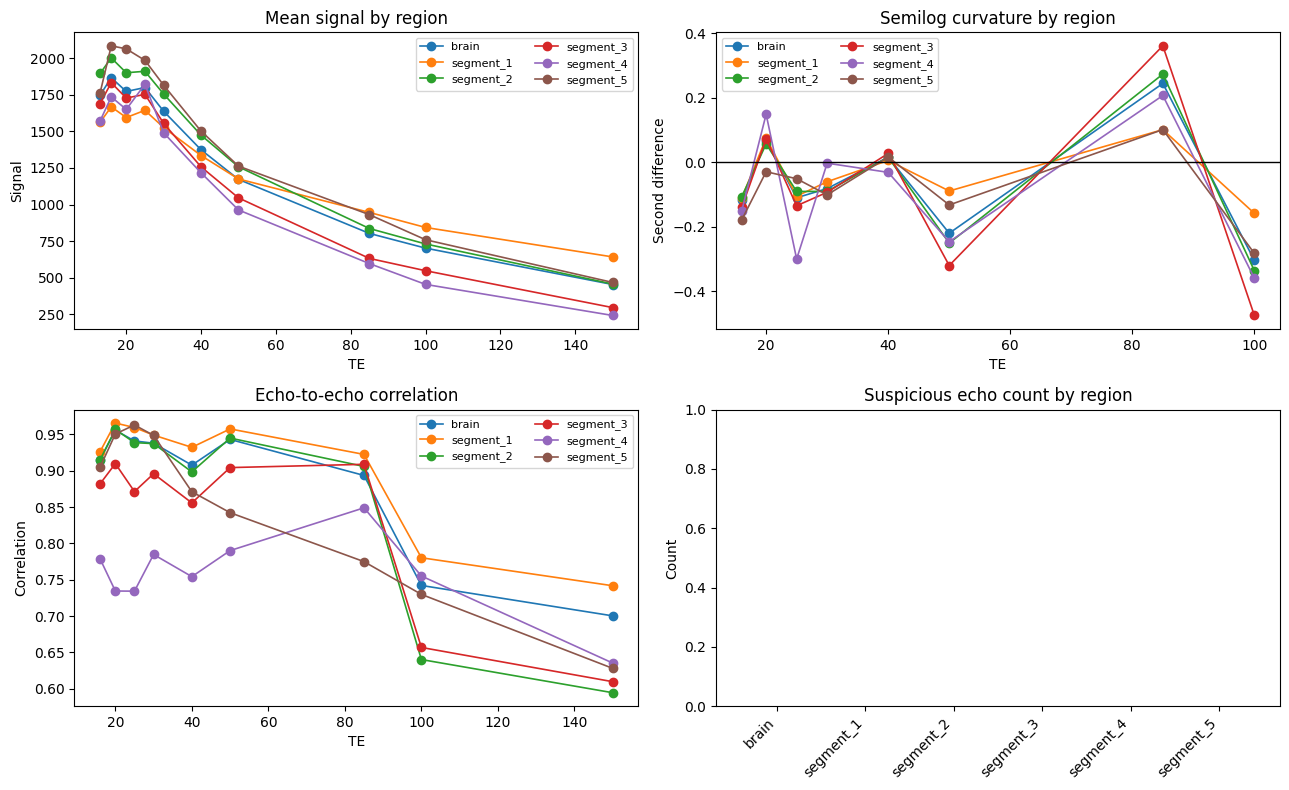

,region,min_echo_corr,max_echo_rms,max_echo_com_shift,n_suspicious_echoes
0,brain,0.700366,423.144019,0.918114,0
1,segment_1,0.741823,469.458164,0.888523,0
2,segment_2,0.594579,457.401047,1.006083,0
3,segment_3,0.609758,432.070951,0.987315,0
4,segment_4,0.635396,388.084643,0.390913,0
5,segment_5,0.628133,595.248380,0.375410,0


In [23]:
motion_results = run_motion_by_region(
    volume=volume,
    echo_times=echo_times,
    region_masks=region_masks,
    show_per_region=False,
    )

motion_summary_rows = []
for region_name, summary in motion_results.items():
    motion_summary_rows.append({
        "region": region_name,
        "min_echo_corr": np.nanmin(summary["successive_correlation"]),
        "max_echo_rms": np.nanmax(summary["successive_rms"]),
        "max_echo_com_shift": np.nanmax(summary["successive_com_shift"]),
        "n_suspicious_echoes": len(summary["suspicious_echoes"]),
    })

display(pd.DataFrame(motion_summary_rows).sort_values("region").reset_index(drop=True))